# ICU Mechanical Ventilation Risk Prediction
## eICU Collaborative Research Database Demo v2.0.1

**Objective:** Build a classification model to predict whether an ICU patient
will require mechanical ventilation in the next 6–12 hours.

**Target variable:** `y_high` = 1 in the 6–12h window before ventilation, 0 otherwise.

**Files used:**
- `patient.csv` — patient demographics & stay info
- `respiratoryCare.csv` — ventilation events (used for labels)
- `respiratoryCharting.csv` — respiratory vitals over time
- `vitalPeriodic.csv` — heart rate, SpO2, respiration rate
- `vitalAperiodic.csv` — non-invasive blood pressure
- `treatment.csv` — clinical treatments applied

## Implementation Plan
1. Data Overview
2. Missing Value Analysis
3. Duplicate Check
4. Target Variable Distribution
5. Univariate Analysis
6. Bivariate Analysis
7. Multivariate Analysis
8. Feature Engineering
9. EDA on Engineered Data Set
10. Key Findings & Summary

<details>
<summary><b>💡 What does y_high mean? (click to expand)</b></summary>
<br>
Think of it like a <b>security camera</b> watching a patient every hour in the ICU.
<br><br>
Every hour we take a snapshot of their vitals (heart rate, SpO2, breathing rate...)
and ask: <b>"Will this patient need a ventilator soon?"</b>
<br><br>
We label each snapshot:
<ul>
  <li><b>y_high = 1 🚨</b> — Danger! Ventilator is coming in 6–12 hours</li>
  <li><b>y_high = 0 ✅</b> — Patient is okay right now</li>
</ul>

The <b>6–12 hour window</b> gives doctors enough warning time — not too early
(signal is too weak), not too late (no time to act).
<br><br>
So the model learns: <i>"When vitals look like THIS... a ventilator is
usually needed 6–12 hours later."</i>
</details>

## 📖 Data Dictionary
Only the columns we will actually use in this project.

<details>
<summary><b>patient.csv — Patient Demographics & Stay Info (click to expand)</b></summary>
<br>

| Column | Type | Description |
|--------|------|-------------|
| `patientunitstayid` | int | Unique ID for each ICU stay — our **join key** across all tables |
| `age` | str/int | Patient age in years. Note: `"> 89"` means over 89 |
| `gender` | str | Male / Female |
| `unittype` | str | Type of ICU (e.g. Med-Surg ICU, SICU, MICU) |
| `admissionheight` | float | Height in cm at admission |
| `admissionweight` | float | Weight in kg at admission |
| `unitdischargeoffset` | int | Minutes from ICU admission to ICU discharge — tells us **how long the patient stayed** |
| `unitdischargestatus` | str | Alive / Expired — tells us if patient **survived** |

</details>

<details>
<summary><b>respiratoryCare.csv — Ventilation Events (used for LABELS only) (click to expand)</b></summary>
<br>

| Column | Type | Description |
|--------|------|-------------|
| `patientunitstayid` | int | Join key |
| `ventstartoffset` | int | Minutes from ICU admission when **ventilation started** — this is how we build `y_high` |

> ⚠️ All other columns in this table are either empty or ventilator settings — not used as features.

</details>

<details>
<summary><b>respiratoryCharting.csv — Respiratory Vitals Over Time (click to expand)</b></summary>
<br>

| Column | Type | Description |
|--------|------|-------------|
| `patientunitstayid` | int | Join key |
| `respchartoffset` | int | Minutes from ICU admission when reading was taken |
| `respchartvaluelabel` | str | Name of the measurement (e.g. FiO2, PEEP, RR) |
| `respchartvalue` | str | The actual value recorded |

**Key measurements we will extract:**

| Label | Description | Normal Range |
|-------|-------------|--------------|
| `FiO2` | Fraction of inspired oxygen (%) | 21% (room air) |
| `RR (patient)` | Patient's respiratory rate (breaths/min) | 12–20 |
| `PEEP` | Positive end-expiratory pressure (cmH₂O) | 3–5 |
| `Tidal Volume (set)` | Volume of air per breath (mL) | 400–500 |
| `LPM O2` | Oxygen flow rate (L/min) | varies |

</details>

<details>
<summary><b>vitalPeriodic.csv — Periodic Vital Signs (click to expand)</b></summary>
<br>

| Column | Type | Description | Normal Range |
|--------|------|-------------|--------------|
| `patientunitstayid` | int | Join key | — |
| `observationoffset` | int | Minutes from ICU admission when reading was taken | — |
| `heartrate` | float | Heart rate (beats/min) | 60–100 |
| `sao2` | float | Oxygen saturation (%) | 95–100 |
| `respiration` | float | Respiratory rate (breaths/min) | 12–20 |

> ⚠️ All other columns (temperature, cvp, etco2, ST segments, icp) are
> 86–99% missing and will be dropped.

</details>

<details>
<summary><b>treatment.csv — Clinical Treatments Applied (click to expand)</b></summary>
<br>

| Column | Type | Description |
|--------|------|-------------|
| `patientunitstayid` | int | Join key |
| `treatmentoffset` | int | Minutes from ICU admission when treatment was applied |
| `treatmentstring` | str | Full treatment description (hierarchical, pipe-separated) |

**Key treatment flags we will extract:**

| Flag | Meaning |
|------|---------|
| `on_oxygen_therapy` | Patient was receiving oxygen |
| `on_bronchodilator` | Patient received bronchodilator |
| `on_noninvasive_vent` | Patient on non-invasive ventilation (BiPAP/CPAP) |

</details>

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# time window (minutes)
WINDOW_LOWER_MIN = 6 * 60   # 6 hours
WINDOW_UPPER_MIN = 12 * 60  # 12 hours

# respirator/ventilator chart labels that may leak
VENT_PARAMS = ['PEEP', 'Tidal Volume (set)', 'Tidal Volume Observed (VT)', 'TV/kg IBW', 'Vent Rate', 'FiO2', 'LPM O2', 'Plateau Pressure']

# column name aliases from your sample
# resp_chart: respchartoffset, respchartvaluelabel, respchartvalue
# resp_care: ventstartoffset
# vitals: observationoffset
# treatment: treatmentoffset

pd.set_option('display.max_columns', None)

 ## Load Data

In [ ]:
path = "/content/"

patient   = pd.read_csv(path + "patient.csv")
resp_care = pd.read_csv(path + "respiratoryCare.csv")
resp_chart= pd.read_csv(path + "respiratoryCharting.csv")
treat     = pd.read_csv(path + "treatment.csv")
# vital_ap  = pd.read_csv(path + "vitalAperiodic.csv")
vital_per = pd.read_csv(path + "vitalPeriodic.csv")

# ---------- Canonicalize time & drop negative offsets ----------
# rename time columns to a common name t_min (minutes)
resp_chart = resp_chart.rename(columns={'respchartoffset':'t_min', 'respchartvaluelabel':'label', 'respchartvalue':'value'})
resp_care  = resp_care.rename(columns={'respcarestatusoffset':'t_min'})  # keep, but vent offsets are separate
vital_per     = vital_per.rename(columns={'observationoffset':'t_min'})
treat  = treat.rename(columns={'treatmentoffset':'t_min'})

# drop obviously invalid negative timepoints (before admission) for time-series tables
resp_chart = resp_chart[resp_chart['t_min'].notna() & (resp_chart['t_min'] >= 0)].copy()
vital_per     = vital_per[vital_per['t_min'].notna() & (vital_per['t_min'] >= 0)].copy()
treat  = treat[treat['t_min'].notna() & (treat['t_min'] >= 0)].copy()

# For resp_care keep all rows (it contains ventstartoffset which may be negative for prior vents),
# but create a cleaned vent_start table next.
# Why: negative offsets in charting/vitals confuse hourly binning and label logic — drop them early.

print("All files loaded!")
print("\nShapes:")
for name, df in [("patient", patient), ("resp_care", resp_care),
                 ("resp_chart", resp_chart), ("treatment", treat),
                  ("vital_periodic", vital_per)]:
    print(f"  {name:20s}: {df.shape}")

All files loaded!

Shapes:
  patient             : (2520, 29)
  resp_care           : (5436, 34)
  resp_chart          : (169817, 7)
  treatment           : (38048, 5)
  vital_periodic      : (1633310, 19)


## 1. Data Overview
Load each table, inspect dimensions, data types, and generate summary statistics.

In [ ]:
for name, df in [("patient", patient), ("resp_care", resp_care),
                 ("resp_chart", resp_chart), ("treatment", treat),
                 ("vital_periodic", vital_per)]:
    print(f"\n{'='*50}")
    print(f"  {name.upper()}")
    print(f"{'='*50}")
    print(df.info())


  PATIENT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          2520 non-null   int64  
 1   patienthealthsystemstayid  2520 non-null   int64  
 2   gender                     2516 non-null   object 
 3   age                        2516 non-null   object 
 4   ethnicity                  2481 non-null   object 
 5   hospitalid                 2520 non-null   int64  
 6   wardid                     2520 non-null   int64  
 7   apacheadmissiondx          2221 non-null   object 
 8   admissionheight            2451 non-null   float64
 9   hospitaladmittime24        2520 non-null   object 
 10  hospitaladmitoffset        2520 non-null   int64  
 11  hospitaladmitsource        1926 non-null   object 
 12  hospitaldischargeyear      2520 non-null   int64  
 13  hospitaldischargetime24    2520 non-n

**Statistics**

In [ ]:
for name, df in [("patient", patient), ("resp_care", resp_care),
                 ("vital_periodic", vital_per)]:
    print(f"\n{'='*50}")
    print(f"  {name.upper()} — describe()")
    print(f"{'='*50}")
    display(df.describe().T)


  PATIENT — describe()


,count,mean,std,min,25%,50%,75%,max
patientunitstayid,2520.0,1.666226e+06,1.022224e+06,141764.0,772262.750,1590372.50,2697421.75,3353113.0
patienthealthsystemstayid,2520.0,1.326635e+06,8.311521e+05,129391.0,593800.000,1230992.50,2165279.00,2742979.0
hospitalid,2520.0,2.610425e+02,1.191098e+02,56.0,158.000,252.50,384.50,459.0
wardid,2520.0,6.293060e+02,3.180836e+02,82.0,376.000,626.00,957.00,1111.0
admissionheight,2451.0,1.697404e+02,1.598609e+01,0.3,162.600,170.20,177.80,600.0
hospitaladmitoffset,2520.0,-2.017726e+03,7.217012e+03,-251404.0,-1173.250,-270.00,-92.00,8696.0
hospitaldischargeyear,2520.0,2.014522e+03,4.996051e-01,2014.0,2014.000,2015.00,2015.00,2015.0
hospitaldischargeoffset,2520.0,8.026446e+03,9.352902e+03,20.0,2606.500,5474.50,9996.75,143016.0
unitvisitnumber,2520.0,1.200000e+00,5.100032e-01,1.0,1.000,1.00,1.00,5.0
admissionweight,2322.0,8.308780e+01,2.660638e+01,0.5,65.500,79.30,96.60,515.0



  RESP_CARE — describe()


,count,mean,std,min,25%,50%,75%,max
respcareid,5436.0,3.593583e+06,1.858971e+06,545261.0,1894299.75,3675473.5,4980134.25,6725944.0
patientunitstayid,5436.0,2.328586e+06,9.730391e+05,147784.0,1439835.00,2728472.0,3233620.00,3353113.0
t_min,5436.0,4.828471e+03,6.546052e+03,-63510.0,763.75,2539.0,6817.00,53158.0
currenthistoryseqnum,5436.0,4.233812e+01,4.930382e+01,1.0,6.00,22.0,61.00,243.0
airwaysize,636.0,7.687107e+00,3.349328e-01,7.0,7.50,7.5,8.00,8.5
cuffpressure,103.0,2.557282e+01,6.103040e+00,0.0,24.00,28.0,30.00,30.0
ventstartoffset,5436.0,-6.009731e+01,1.786050e+03,-45344.0,0.00,0.0,0.00,29563.0
ventendoffset,5436.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.00,0.0
priorventstartoffset,5436.0,-8.544417e+02,4.968548e+03,-45897.0,0.00,0.0,0.00,29563.0
priorventendoffset,5436.0,-6.612914e+01,5.649929e+03,-44902.0,0.00,0.0,0.00,49751.0



  VITAL_PERIODIC — describe()


,count,mean,std,min,25%,50%,75%,max
vitalperiodicid,1633310.0,1.074114e+09,6.632710e+08,71478.00,5.010766e+08,1.116984e+09,1.662815e+09,2.188309e+09
patientunitstayid,1633310.0,1.764497e+06,1.002845e+06,141764.00,9.614400e+05,1.733366e+06,2.743112e+06,3.353113e+06
t_min,1633310.0,5.436791e+03,8.167602e+03,0.00,1.000000e+03,2.510000e+03,6.136000e+03,6.647300e+04
temperature,112817.0,3.867800e+01,9.781033e+00,0.50,3.670000e+01,3.720000e+01,3.770000e+01,1.030000e+02
sao2,1440186.0,9.645510e+01,4.727058e+00,0.00,9.500000e+01,9.700000e+01,9.900000e+01,1.000000e+02
heartrate,1626273.0,8.546417e+01,1.809246e+01,0.00,7.200000e+01,8.400000e+01,9.700000e+01,2.570000e+02
respiration,1380048.0,2.012070e+01,6.695883e+00,0.00,1.600000e+01,1.900000e+01,2.300000e+01,1.880000e+02
cvp,202242.0,3.653264e+01,7.785600e+01,-50.00,7.000000e+00,1.200000e+01,1.800000e+01,4.000000e+02
etco2,72763.0,2.947042e+01,1.207231e+01,0.00,2.600000e+01,3.000000e+01,3.600000e+01,1.940000e+02
systemicsystolic,226394.0,1.242745e+02,2.574268e+01,-44.00,1.070000e+02,1.220000e+02,1.400000e+02,3.490000e+02


In [ ]:
print("=== PATIENT ===")
display(patient.head())

print("=== RESP_CARE ===")
display(resp_care.head())

print("=== VITAL_PERIODIC ===")
display(vital_per.head())

=== PATIENT ===


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,hospitaladmitoffset,hospitaladmitsource,hospitaldischargeyear,hospitaldischargetime24,hospitaldischargeoffset,hospitaldischargelocation,hospitaldischargestatus,unittype,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141764,129391,Female,87,Caucasian,59,91,NaN,157.5,23:36:00,-2258,NaN,2015,19:20:00,366,Home,Alive,Med-Surg ICU,13:14:00,ICU to SDU,2,stepdown/other,NaN,NaN,18:58:00,344,Home,Alive,002-1039
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,-8,NaN,2015,19:20:00,2616,Home,Alive,Med-Surg ICU,23:44:00,Emergency Department,1,admit,46.5,45.0,13:14:00,2250,Step-Down Unit (SDU),Alive,002-1039
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,-1,Operating Room,2014,17:05:00,1218,Home,Alive,SICU,20:47:00,Operating Room,1,admit,77.5,79.4,10:00:00,793,Floor,Alive,002-12289
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,-23,Emergency Department,2015,21:05:00,1138,Other Hospital,Alive,Med-Surg ICU,02:07:00,Emergency Department,1,admit,60.3,60.7,20:48:00,1121,Other External,Alive,002-1116
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,-10,Emergency Department,2014,15:41:00,5263,Home,Alive,SICU,23:58:00,Operating Room,1,admit,91.7,93.1,22:47:00,1369,Floor,Alive,002-12243


=== RESP_CARE ===


,respcareid,patientunitstayid,t_min,currenthistoryseqnum,airwaytype,airwaysize,airwayposition,cuffpressure,ventstartoffset,ventendoffset,priorventstartoffset,priorventendoffset,apneaparams,lowexhmvlimit,hiexhmvlimit,lowexhtvlimit,hipeakpreslimit,lowpeakpreslimit,hirespratelimit,lowrespratelimit,sighpreslimit,lowironoxlimit,highironoxlimit,meanairwaypreslimit,peeplimit,cpaplimit,setapneainterval,setapneatv,setapneaippeephigh,setapnearr,setapneapeakflow,setapneainsptime,setapneaie,setapneafio2
0,564013,147784,1188,2,NaN,NaN,NaN,NaN,0,0,-361,542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,564012,147784,-61,1,NaN,NaN,NaN,NaN,-361,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,545261,165840,-63,1,NaN,NaN,NaN,NaN,-363,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,545262,165840,73,2,NaN,NaN,NaN,NaN,0,0,-363,-227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,550472,187150,7293,2,NaN,NaN,NaN,NaN,0,0,-522,7424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== VITAL_PERIODIC ===


,vitalperiodicid,patientunitstayid,t_min,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp
0,29524122,141765,1179,NaN,NaN,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29557845,141765,189,NaN,97.0,76.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29524442,141765,1169,NaN,NaN,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29513052,141765,1534,NaN,NaN,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29524600,141765,1164,NaN,NaN,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Overview — Key Observations

<details>
<summary><b>patient table (click to expand)</b></summary>
<br>

- `age` is stored as **string** (object type) because of `"> 89"` values — needs conversion before use
- `admissionheight` has a max of **600 cm** → impossible, clear outlier to fix
- `admissionweight` has a max of **515 kg** → suspicious, needs outlier treatment
- `dischargeweight` is **51% missing** → will drop this column entirely
- `unitdischargeoffset` has **12 rows = 0** → patients with zero stay length, need to investigate

</details>

<details>
<summary><b>resp_care table (click to expand)</b></summary>
<br>

- This table is used **only for labels** (ventstartoffset), not as a feature source
- `ventendoffset` is **all zeros** → completely useless column, will drop
- 5 columns have **zero non-null values** (sighpreslimit, lowironoxlimit, highironoxlimit, meanairwaypreslimit, setapneaie) → will drop
- `ventstartoffset` has negative values (ventilation started before ICU admission) → need to filter these out

</details>

<details>
<summary><b>vital_periodic table (click to expand)</b></summary>
<br>

- `heartrate` min = **0** → impossible for a living patient, needs cleaning
- `sao2` min = **0** → physiologically impossible, needs cleaning  
- `respiration` max = **188 breaths/min** and min = **0** → both ends are impossible, needs cleaning
- Only **3 columns are usable**: heartrate, sao2, respiration — everything else is 86–99% missing

</details>

<details>
<summary><b>resp_chart table (click to expand)</b></summary>
<br>

- Data is in **long format** (one row per measurement) — needs to be pivoted into wide format for ML
- `respchartvalue` is stored as **string** → needs conversion to numeric
- Key signals: FiO2 (27k records), RR (22k), PEEP (13k), Tidal Volume (11k)

</details>

<details>
<summary><b>treatment table (click to expand)</b></summary>
<br>

- No missing values ✅
- `treatmentstring` is **hierarchical** (pipe-separated) — we'll extract binary flags from it
- 1,381 records mention mechanical ventilation — useful to cross-validate our labels

</details>

In [ ]:
# ---------- Extract earliest positive ventilation-start per patient ----------
# ventstartoffset exists in resp_care rows (0 or >0 in your sample indicates vent event)
vent_df = resp_care[['patientunitstayid','ventstartoffset']].copy()
# keep only positive vents; use the earliest positive vent as the event time
vent_df = vent_df[vent_df['ventstartoffset'].notna() & (vent_df['ventstartoffset'] > 0)]
vent_start = vent_df.groupby('patientunitstayid', as_index=False)['ventstartoffset'].min().rename(columns={'ventstartoffset':'vent_start_min'})
# quick sanity
print('vent_start rows:', len(vent_start))
vent_start.head()

vent_start rows: 69


,patientunitstayid,vent_start_min
0,197619,310
1,202294,433
2,230427,3818
3,325924,1043
4,341782,1075


# 2. Missing Value Analysis


Identify missing values per column, visualize the missing patterns,
and assess whether missingness is random or systematic.

In [ ]:
print("=== MISSING VALUES (%) PER COLUMN ===\n")

for name, df in [("patient", patient), ("resp_care", resp_care),
                 ("resp_chart", resp_chart), ("treatment", treat),
                 ("vital_periodic", vital_per)]:
    miss = (df.isna().sum() / len(df) * 100).round(1)
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{'─'*40}")
    print(f"  {name.upper()}")
    print(f"{'─'*40}")
    if len(miss):
        print(miss.to_string())
    else:
        print("  ✅ No missing values!")

=== MISSING VALUES (%) PER COLUMN ===


────────────────────────────────────────
  PATIENT
────────────────────────────────────────
dischargeweight              51.0
hospitaladmitsource          23.6
apacheadmissiondx            11.9
admissionweight               7.9
admissionheight               2.7
ethnicity                     1.5
hospitaldischargelocation     1.3
hospitaldischargestatus       1.1
unitadmitsource               0.9
age                           0.2
gender                        0.2
unitdischargelocation         0.2
unitdischargestatus           0.1

────────────────────────────────────────
  RESP_CARE
────────────────────────────────────────
sighpreslimit          100.0
lowironoxlimit         100.0
highironoxlimit        100.0
meanairwaypreslimit    100.0
setapneaie             100.0
setapneaippeephigh      99.6
cuffpressure            98.1
apneaparams             98.0
setapneainsptime        97.9
lowpeakpreslimit        96.7
peeplimit               96.3
setapneatv  

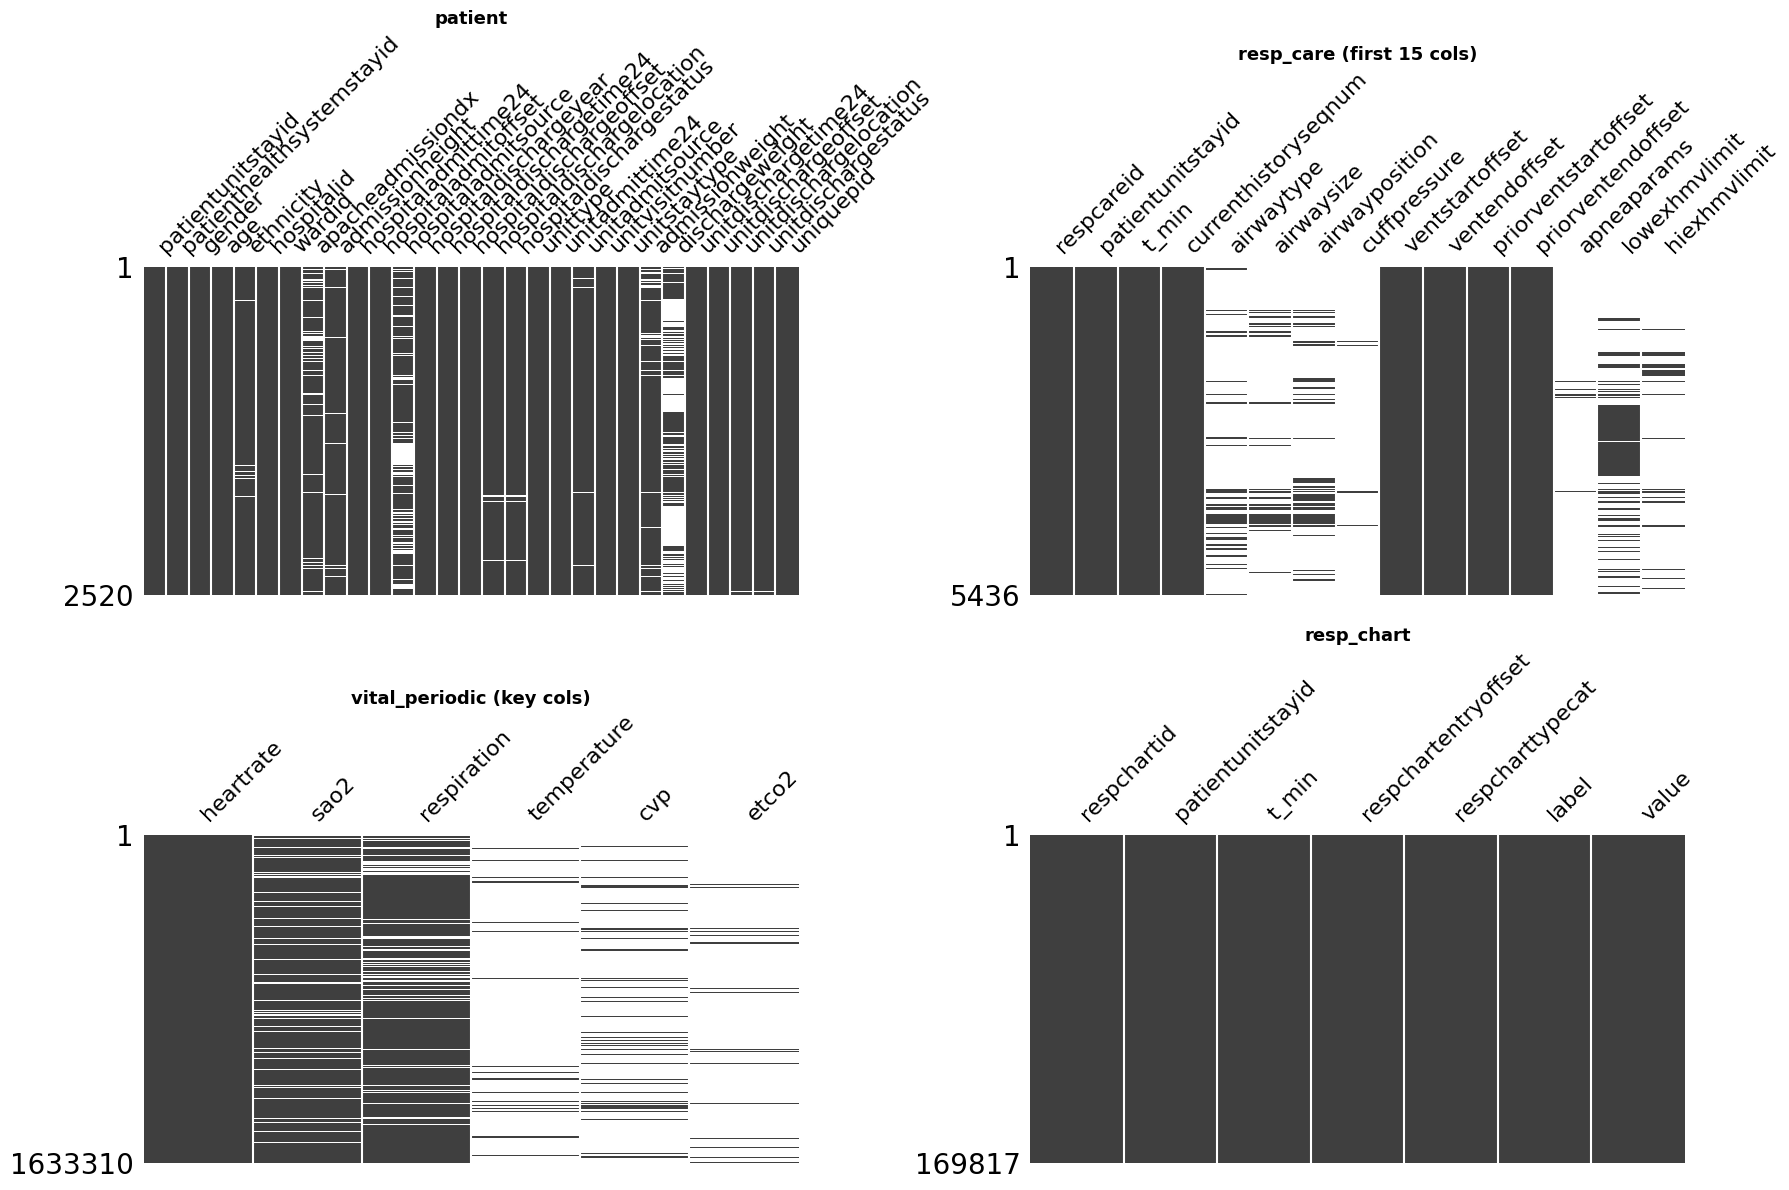

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

msno.matrix(patient, ax=axes[0,0], sparkline=False)
axes[0,0].set_title("patient", fontsize=13, fontweight='bold')

msno.matrix(resp_care.iloc[:, :15], ax=axes[0,1], sparkline=False)
axes[0,1].set_title("resp_care (first 15 cols)", fontsize=13, fontweight='bold')

msno.matrix(vital_per[['heartrate','sao2','respiration',
                        'temperature','cvp','etco2']],
            ax=axes[1,0], sparkline=False)
axes[1,0].set_title("vital_periodic (key cols)", fontsize=13, fontweight='bold')

msno.matrix(resp_chart, ax=axes[1,1], sparkline=False)
axes[1,1].set_title("resp_chart", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Findings and Insights — Missing Data Analysis

### 1. Patient Table

Several variables in the `patient` table contain **moderate missingness**.  
The variable `dischargeweight` has the highest proportion of missing values (about 51%).
Other variables such as `hospitaladmitsource` (about 23.6%) and `apacheadmissiondx` (about 11.9%) also contain missing values.

However, most demographic variables — including `gender`, `age`, and discharge status fields — contain **very low missingness (<1%)**.

**Insight:**  
Demographic and admission-related features are largely complete and can likely be retained using simple imputation techniques for the missing values.

---

### 2. Respiratory Care Table (`resp_care`)

Many variables in this table contain **extremely high missingness (90–100%)**.  
These include several ventilator configuration parameters such as pressure limits, apnea settings, and oxygen limits.

**Insight:**  
These parameters likely represent measurements recorded only in **specific clinical scenarios or device configurations**. Because the majority of these variables are almost entirely missing, many of them will likely be **excluded from further analysis or modeling**.

---

### 3. Respiratory Chart Table (`resp_chart`)

The variable `respchartvalue` shows **almost no missing data (~0.1%)**.

**Insight:**  
This table appears to be **well populated and reliable**, suggesting that it may contain useful respiratory measurements for downstream analysis.

---

### 4. Treatment Table (`treatment`)

No missing values were detected in the treatment table.

**Insight:**  
The completeness of this table suggests it may be a **reliable source for feature engineering related to clinical interventions**.

---

### 5. Vital Signs Table (`vital_periodic`)

Several variables in this table exhibit **very high missingness**, including measurements such as `icp`, `padiastolic`, and `pasystolic`.

However, key physiological variables show much lower missingness:
- `heartrate` (~0.4%)
- `sao2` (~11.8%)
- `respiration` (~15.5%)

**Insight:**  
Core vital signs appear to be consistently recorded and will likely serve as **important predictors in later modeling stages**.

---

### Overall Observation

The dataset shows **heterogeneous missingness patterns**, where certain clinical variables are nearly absent while core physiological measurements remain relatively complete.

This pattern suggests that some measurements are **only recorded under specific medical conditions**, rather than being missing due to data quality issues.

Careful preprocessing and feature selection will therefore be required before building machine learning models.

## Missing Data Handling Strategy

Based on the missing data analysis, the following preprocessing strategy will be applied:

1. Columns with **extremely high missingness (>90%)** will be removed, as they provide limited usable information.
2. Variables with **moderate missingness** will be handled using appropriate imputation methods:
   - Numerical variables → median imputation
   - Categorical variables → mode imputation
3. Key physiological measurements from the vital signs table will be retained and handled carefully due to their clinical importance.
4. Additional feature engineering may be performed after cleaning to ensure that useful clinical signals are preserved.

In [ ]:
## Missing Data Handling Strategy

# Based on the missing data analysis, the following preprocessing strategy is applied:
# 1️⃣ Drop columns with extremely high missingness (>90%)
# 2️⃣ Impute moderate-missing variables (median for numeric, mode for categorical)
# 3️⃣ Retain key physiological measurements for EDA
# 4️⃣ Additional feature engineering will follow after cleaning

# -----------------------------
# Drop extremely sparse columns
# -----------------------------

# RESP_CARE columns (~90–100% missing + remaining high missing)
resp_care_cols_to_drop = [
    'sighpreslimit','lowironoxlimit','highironoxlimit','meanairwaypreslimit',
    'setapneaie','setapneaippeephigh','cuffpressure','apneaparams',
    'setapneainsptime','lowpeakpreslimit','peeplimit','setapneatv',
    'setapneapeakflow','setapneafio2','setapnearr','cpaplimit',
    'setapneainterval','lowrespratelimit','hipeakpreslimit','hiexhmvlimit',
    'lowexhtvlimit','airwaysize','airwaytype','hirespratelimit','airwayposition','lowexhmvlimit'
]

resp_care = resp_care.drop(columns=resp_care_cols_to_drop)

# VITAL_PERIODIC columns (>90% missing + mostly empty)
vital_per_cols_to_drop = [
    'icp','padiastolic','pasystolic','pamean','etco2','temperature',
    'cvp','systemicsystolic','systemicdiastolic','systemicmean','st1','st2','st3'
]

vital_per = vital_per.drop(columns=vital_per_cols_to_drop)

# -----------------------------
# Impute key vitals for EDA
# -----------------------------
key_vitals = ['heartrate','sao2','respiration']
for col in key_vitals:
    vital_per[col] = vital_per[col].fillna(vital_per[col].median())

# -----------------------------
# Verify remaining missing values
# -----------------------------
print("Remaining missing in resp_care:\n", resp_care.isna().sum().sort_values(ascending=False).head(10))
print("Remaining missing in vital_per:\n", vital_per.isna().sum())

Remaining missing in resp_care:
 respcareid              0
patientunitstayid       0
t_min                   0
currenthistoryseqnum    0
ventstartoffset         0
ventendoffset           0
priorventstartoffset    0
priorventendoffset      0
dtype: int64
Remaining missing in vital_per:
 vitalperiodicid      0
patientunitstayid    0
t_min                0
sao2                 0
heartrate            0
respiration          0
dtype: int64


## Patient Table: Column Selection & Missing Data Strategy

- **Dropped**
  - `dischargeweight`: post-ICU measurement, high missingness (~51%), not predictive for ventilation risk.
- **Kept and imputed**
  - `admissionweight` (~8% missing) → median imputation, baseline numeric feature.
  - `admissionheight` (~2.7% missing) → median imputation, may be used to calculate BMI.
  - `hospitaladmitsource` (~23.6% missing) → mode imputation, categorical baseline feature.
  - `apacheadmissiondx` (~11.9% missing) → mode imputation, categorical admission diagnosis.

This ensures only **pre-admission and clinically relevant features** are used for EDA and modeling.

In [ ]:
# -----------------------------
# Patient Table: Missing Data Handling (Full, Corrected)
# -----------------------------

# Drop post-ICU column
patient = patient.drop(columns=['dischargeweight'])

# Handle 'age' special case: '>89' → 90
patient['age'] = patient['age'].replace('>89', 90)

# Columns to impute
numeric_cols = ['admissionweight','admissionheight','age']   # median imputation
categorical_cols = [
    'hospitaladmitsource','apacheadmissiondx',
    'ethnicity','hospitaldischargelocation','hospitaldischargestatus',
    'unitadmitsource','unitdischargelocation','unitdischargestatus','gender'
]  # mode imputation

# Convert numeric columns to proper numeric type
for col in numeric_cols:
    patient[col] = pd.to_numeric(patient[col], errors='coerce')

# Median imputation for numeric columns
for col in numeric_cols:
    patient[col] = patient[col].fillna(patient[col].median())

# Mode imputation for categorical columns
for col in categorical_cols:
    patient[col] = patient[col].fillna(patient[col].mode()[0])

# Verify remaining missing values
print("Remaining missing in patient table:\n", patient.isna().sum().sort_values(ascending=False))

Remaining missing in patient table:
 patientunitstayid            0
patienthealthsystemstayid    0
gender                       0
age                          0
ethnicity                    0
hospitalid                   0
wardid                       0
apacheadmissiondx            0
admissionheight              0
hospitaladmittime24          0
hospitaladmitoffset          0
hospitaladmitsource          0
hospitaldischargeyear        0
hospitaldischargetime24      0
hospitaldischargeoffset      0
hospitaldischargelocation    0
hospitaldischargestatus      0
unittype                     0
unitadmittime24              0
unitadmitsource              0
unitvisitnumber              0
unitstaytype                 0
admissionweight              0
unitdischargetime24          0
unitdischargeoffset          0
unitdischargelocation        0
unitdischargestatus          0
uniquepid                    0
dtype: int64


In [ ]:
# -----------------------------
# Respiratory Chart Table: Missing Data Handling
# -----------------------------

# respchartvalue → very few missing (~0.1%), safe to drop
resp_chart = resp_chart.dropna(subset=['value'])


In [ ]:
# -----------------------------
# Final Missing Values Audit
# -----------------------------

tables = {
    "patient": patient,
    "resp_care": resp_care,
    "vital_periodic": vital_per,
    "resp_chart": resp_chart,
    "treatment": treat
}

print("=== Remaining Missing Values per Table ===\n")

for name, df in tables.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        print(f"{name}: ✅ No missing values remaining\n")
    else:
        print(f"{name}:\n{missing}\n")

=== Remaining Missing Values per Table ===

patient: ✅ No missing values remaining

resp_care: ✅ No missing values remaining

vital_periodic: ✅ No missing values remaining

resp_chart: ✅ No missing values remaining

treatment: ✅ No missing values remaining



In [ ]:
# -----------------------------
# Remaining Columns in All Tables
# -----------------------------

tables = {
    "patient": patient,
    "resp_care": resp_care,
    "vital_periodic": vital_per,
    "resp_chart": resp_chart,
    "treatment": treat
}

for name, df in tables.items():
    print(f"{name} ({df.shape[1]} columns):")
    print(list(df.columns))
    print("\n")

patient (28 columns):
['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset', 'hospitaladmitsource', 'hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid']


resp_care (8 columns):
['respcareid', 'patientunitstayid', 't_min', 'currenthistoryseqnum', 'ventstartoffset', 'ventendoffset', 'priorventstartoffset', 'priorventendoffset']


vital_periodic (6 columns):
['vitalperiodicid', 'patientunitstayid', 't_min', 'sao2', 'heartrate', 'respiration']


resp_chart (7 columns):
['respchartid', 'patientunitstayid', 't_min', 'respchartentryoffset', 'respcharttypecat', 'label', '

**Feature Selection Strategy**

At this stage, we will not drop any additional columns except those that are clearly post-outcome or purely identifiers (e.g., dischargeweight).

Reasoning

* Some columns that may initially seem unrelated could still carry subtle predictive signals.

* Dropping columns too early can limit later analysis or feature engineering.

* Keeping all candidate features allows us to objectively evaluate their relationship with the target variable before removing them.

## Outlier Treatment — Raw Tables
Fixing physiologically impossible values found during univariate analysis.
Outliers in vital signs (heartrate, sao2, respiration) are handled later
in Step 4 during feature engineering using merge_asof alignment.

In [ ]:
# ── Outlier Treatment — Raw Tables ───────────────────────────────
print("BEFORE cleaning:")
print(f"  admissionheight max: {patient['admissionheight'].max()}")
print(f"  admissionweight max: {patient['admissionweight'].max()}")

# admissionheight: normal range 100–250cm
patient.loc[patient['admissionheight'] > 250, 'admissionheight'] = np.nan
patient.loc[patient['admissionheight'] < 100, 'admissionheight'] = np.nan

# admissionweight: normal range 20–300kg
patient.loc[patient['admissionweight'] > 300, 'admissionweight'] = np.nan
patient.loc[patient['admissionweight'] < 20,  'admissionweight'] = np.nan

# Impute newly created NaNs with median
patient['admissionheight'] = patient['admissionheight'].fillna(
    patient['admissionheight'].median())
patient['admissionweight'] = patient['admissionweight'].fillna(
    patient['admissionweight'].median())

print("\nAFTER cleaning:")
print(f"  admissionheight max: {patient['admissionheight'].max()}")
print(f"  admissionweight max: {patient['admissionweight'].max()}")
print(f"  admissionheight min: {patient['admissionheight'].min()}")
print(f"  admissionweight min: {patient['admissionweight'].min()}")

BEFORE cleaning:
  admissionheight max: 600.0
  admissionweight max: 515.0

AFTER cleaning:
  admissionheight max: 204.5
  admissionweight max: 293.93
  admissionheight min: 109.7
  admissionweight min: 32.7


# 3. Duplicate Handling Strategy



- **Patient table:** Patient table – duplicates usually don’t make sense; each patient stay should be unique. Check for duplicates and remove any exact duplicate rows.  
- **Respiratory Care, Vital Periodic, Respiratory Chart, Treatment tables:** Do not remove duplicates automatically, as repeated entries can represent valid measurements or events. These tables are long-format time-series or event logs, so repeated rows may be valid records.

✅ This ensures we maintain **all legitimate clinical records** while keeping the patient-level data clean.

In [ ]:
# -----------------------------
# Patient Table: Duplicate Check
# -----------------------------

# Count duplicates
patient_dup_count = patient.duplicated().sum()
print(f"Patient table duplicates: {patient_dup_count}")

# Drop duplicates if any
if patient_dup_count > 0:
    patient = patient.drop_duplicates()
    print(f"Duplicates dropped. New shape: {patient.shape}")
else:
    print("No duplicates to drop in patient table.")

Patient table duplicates: 0
No duplicates to drop in patient table.




---
# 4. Target Variable Analysis


How many patients got ventilated? When? This defines our prediction problem.

In [ ]:
# How many patients got ventilated after ICU admission?
vent = resp_care[resp_care['ventstartoffset'] > 0].copy()
vent_patients = vent.groupby('patientunitstayid')['ventstartoffset'].min().reset_index()
vent_patients.columns = ['patientunitstayid', 'vent_start_min']

total_patients = patient['patientunitstayid'].nunique()
vent_count = vent_patients['patientunitstayid'].nunique()

print(f"Total ICU patients:        {total_patients}")
print(f"Ventilated patients:       {vent_count}")
print(f"Non-ventilated patients:   {total_patients - vent_count}")
print(f"Ventilation rate:          {vent_count/total_patients*100:.1f}%")

print(f"\nVentilation start time (minutes from ICU admission):")
print(vent_patients['vent_start_min'].describe().round(0))

Total ICU patients:        2520
Ventilated patients:       69
Non-ventilated patients:   2451
Ventilation rate:          2.7%

Ventilation start time (minutes from ICU admission):
count       69.0
mean      4085.0
std       6399.0
min         11.0
25%        544.0
50%       1619.0
75%       3818.0
max      29563.0
Name: vent_start_min, dtype: float64


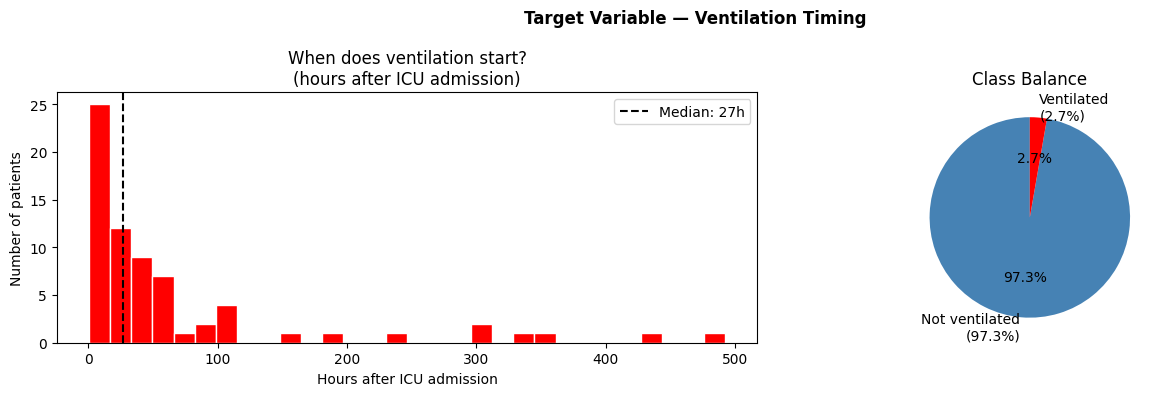

In [ ]:
# Ventilation timing — WHEN do patients get ventilated?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target Variable — Ventilation Timing', fontweight='bold')

# Distribution of vent start times
vent_hours = vent_patients['vent_start_min'] / 60
axes[0].hist(vent_hours, bins=30, color='red', edgecolor='white')
axes[0].set_title('When does ventilation start?\n(hours after ICU admission)')
axes[0].set_xlabel('Hours after ICU admission')
axes[0].set_ylabel('Number of patients')
axes[0].axvline(vent_hours.median(), color='black',
                linestyle='--', label=f'Median: {vent_hours.median():.0f}h')
axes[0].legend()

# Ventilated vs not pie
axes[1].pie([total_patients - vent_count, vent_count],
            labels=['Not ventilated\n(97.3%)', 'Ventilated\n(2.7%)'],
            colors=['steelblue', 'red'], autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.show()

### Target Variable — Key Observations

- Only **69 out of 2,520 patients (2.7%)** needed mechanical ventilation → severe class imbalance
- Ventilation happened anywhere from **11 minutes** to **~20 days** after ICU admission
- **50% of ventilated patients** were intubated within the first **~27 hours** (1619 min)
- This confirms we need a class imbalance strategy (SMOTE or class weights) during modeling

> ⚠️ The 2.7% ventilation rate means our model will see ~97 "safe" hours for every 1 "danger" hour



---
# 5. Univariate Analysis



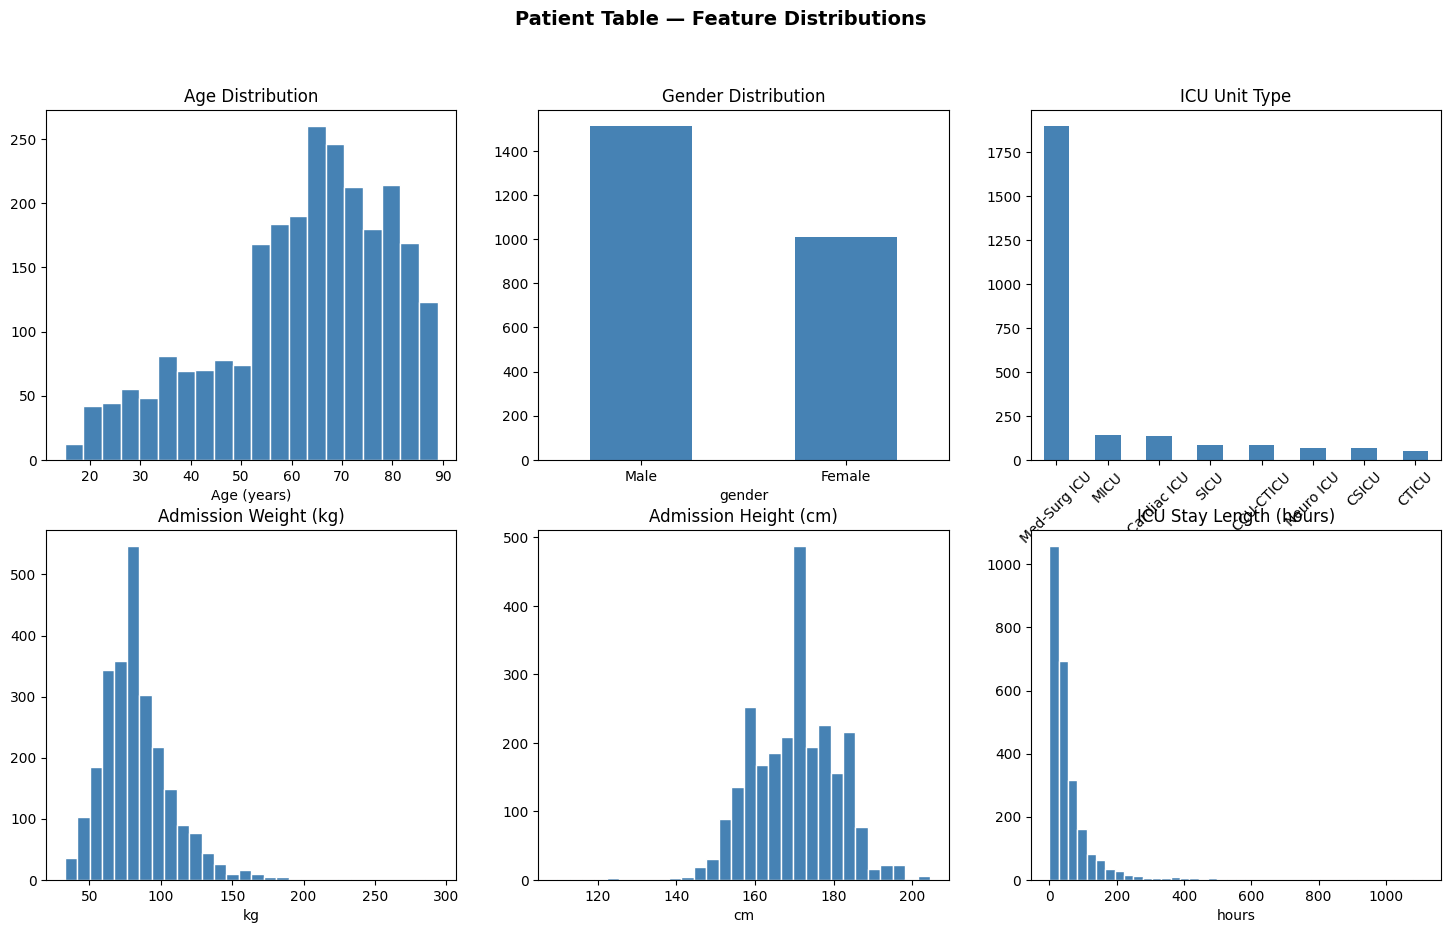

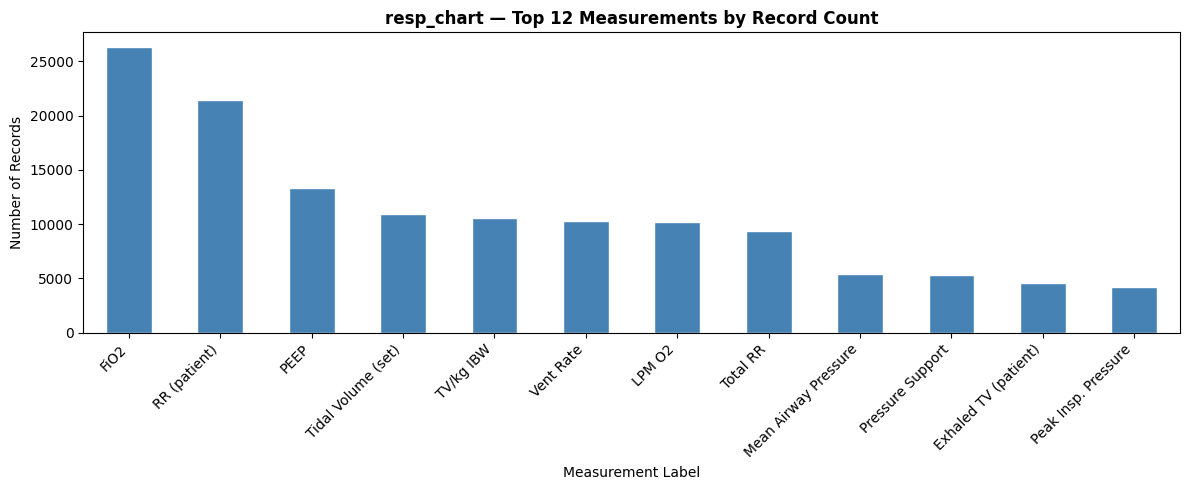

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Patient Table — Feature Distributions', fontsize=14, fontweight='bold')

# Age (clean > 89 first for plotting)
age_clean = pd.to_numeric(patient['age'].replace('> 89', 90), errors='coerce')
axes[0,0].hist(age_clean.dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age (years)')

# Gender
patient['gender'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Gender Distribution')
axes[0,1].tick_params(axis='x', rotation=0)

# Unit Type
patient['unittype'].value_counts().plot(kind='bar', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('ICU Unit Type')
axes[0,2].tick_params(axis='x', rotation=45)

# Admission Weight
axes[1,0].hist(patient['admissionweight'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1,0].set_title('Admission Weight (kg)')
axes[1,0].set_xlabel('kg')

# Admission Height
axes[1,1].hist(patient['admissionheight'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1,1].set_title('Admission Height (cm)')
axes[1,1].set_xlabel('cm')

# Unit Stay Length
stay_hours = patient['unitdischargeoffset'] / 60
axes[1,2].hist(stay_hours.dropna(), bins=40, color='steelblue', edgecolor='white')
axes[1,2].set_title('ICU Stay Length (hours)')
axes[1,2].set_xlabel('hours')

# Resp chart — visualize top measurements
top_labels = resp_chart['label'].value_counts().head(12)

plt.figure(figsize=(12, 5))
top_labels.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('resp_chart — Top 12 Measurements by Record Count',
          fontweight='bold')
plt.xlabel('Measurement Label')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

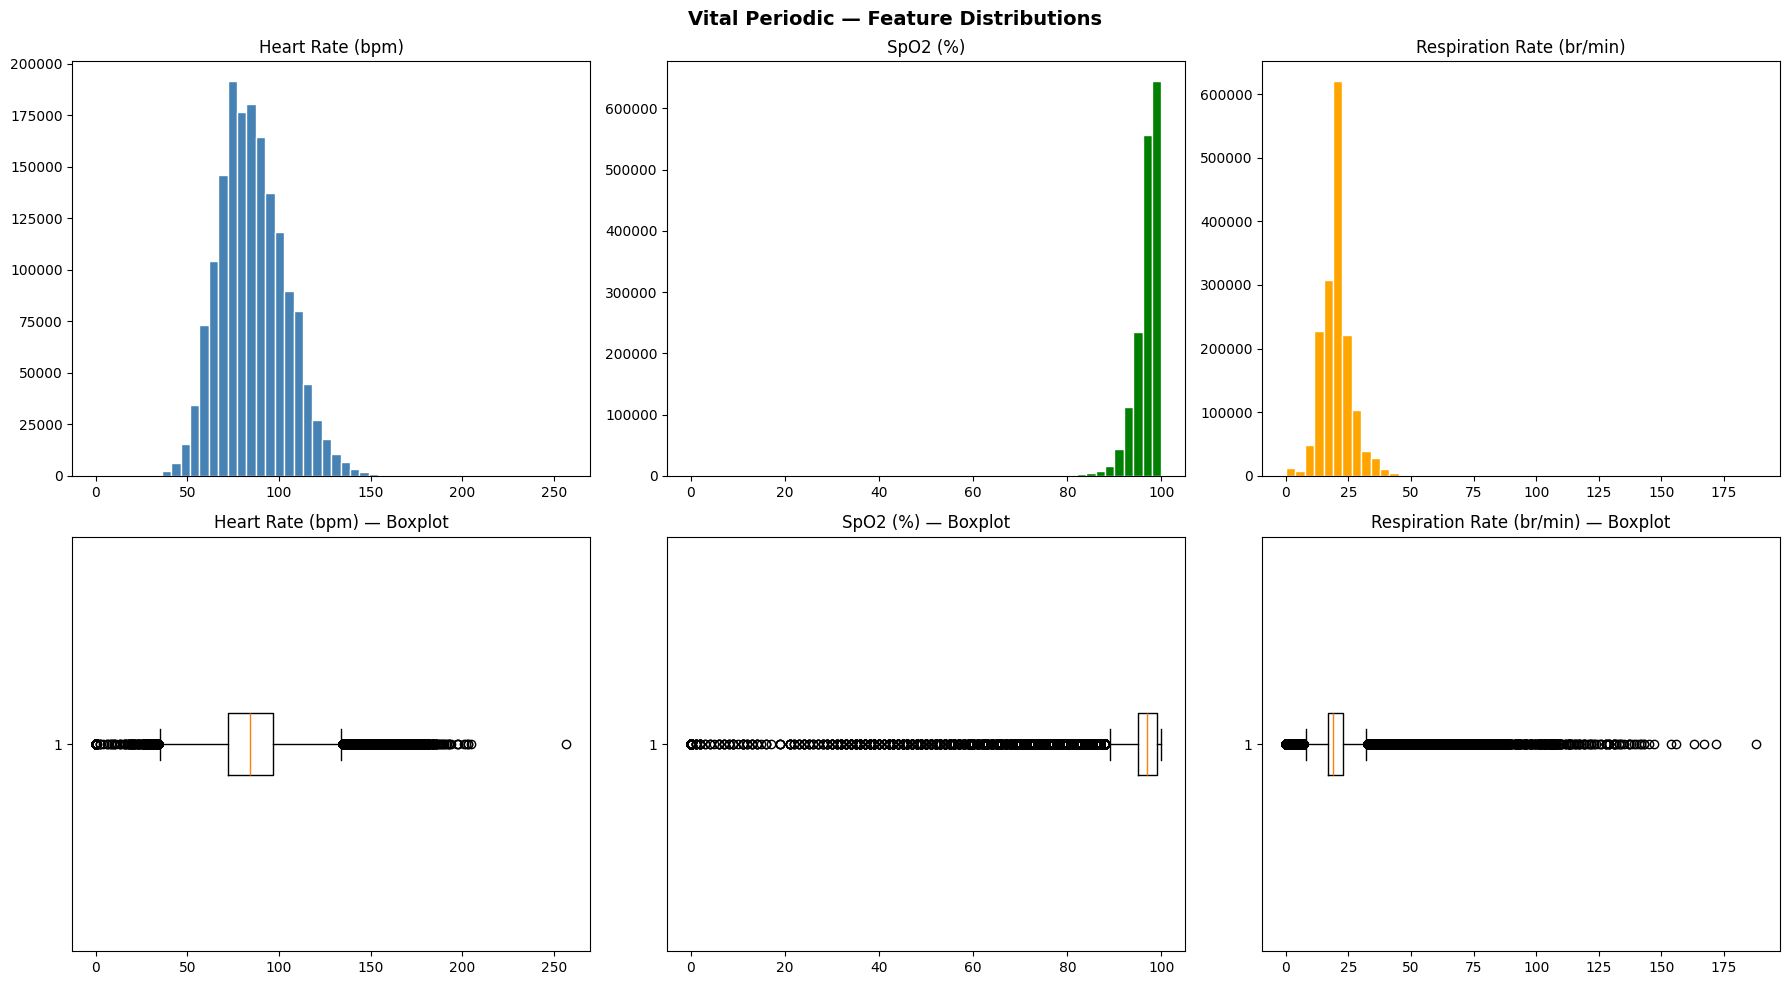

=== SUSPICIOUS VALUES ===
heartrate <= 0:    335
heartrate > 250:   1
sao2 < 50:         1985
respiration <= 0:  11470
respiration > 80:  429


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Vital Periodic — Feature Distributions', fontsize=14, fontweight='bold')

vitals = {
    'heartrate':   (axes[0,0], 'Heart Rate (bpm)',        'steelblue'),
    'sao2':        (axes[0,1], 'SpO2 (%)',                 'green'),
    'respiration': (axes[0,2], 'Respiration Rate (br/min)','orange'),
}

for col, (ax, title, color) in vitals.items():
    ax.hist(vital_per[col].dropna(), bins=50, color=color, edgecolor='white')
    ax.set_title(title)


# Boxplots for outlier view
for i, (col, (ax, title, color)) in enumerate(vitals.items()):
    axes[1,i].boxplot(vital_per[col].dropna(), vert=False)
    axes[1,i].set_title(f'{title} — Boxplot')

plt.tight_layout()
plt.show()

# Print suspicious values
print("=== SUSPICIOUS VALUES ===")
print(f"heartrate <= 0:    {(vital_per['heartrate'] <= 0).sum()}")
print(f"heartrate > 250:   {(vital_per['heartrate'] > 250).sum()}")
print(f"sao2 < 50:         {(vital_per['sao2'] < 50).sum()}")
print(f"respiration <= 0:  {(vital_per['respiration'] <= 0).sum()}")
print(f"respiration > 80:  {(vital_per['respiration'] > 80).sum()}")

In [ ]:
# What measurements exist and how many?
print("=== RESP CHART — Top measurements ===")
print(resp_chart['label'].value_counts().head(20))

=== RESP CHART — Top measurements ===
label
FiO2                     26368
RR (patient)             21444
PEEP                     13363
Tidal Volume (set)       10901
TV/kg IBW                10519
Vent Rate                10305
LPM O2                   10168
Total RR                  9345
Mean Airway Pressure      5399
Pressure Support          5314
Exhaled TV (patient)      4593
Peak Insp. Pressure       4180
Exhaled MV                3795
SaO2                      3625
O2 Device                 3006
Flow Sensitivity          2643
Plateau Pressure          2477
Exhaled TV (machine)      2440
Head of Bed Elevation     2208
Compliance                1554
Name: count, dtype: int64


## Univariate Analysis — Key Observations

### Patient Table
- **Age** ✅ → good distribution, peaks around 65–70 (typical ICU population) — **KEEP**
- **Gender** ✅ → more males than females, reasonable — **KEEP**
- **ICU Unit Type** ✅ → mostly Med-Surg ICU then MICU — **KEEP** (MICU patients more likely to need ventilation)
- **Admission Weight** ⚠️ → right skewed but values up to **515kg** → impossible, needs outlier treatment — **KEEP after cleaning**
- **Admission Height** ⚠️ → huge spike at ~170cm (normal) but values up to **600cm** → clearly wrong entries — **KEEP after cleaning**
- **ICU Stay Length** ✅ → right skewed, most < 100 hours, makes sense — used for grid only

### Vital Signs (vital_periodic)
- **Heart Rate** ✅ → nice distribution centered ~80 bpm, but boxplot shows outliers near 0 and >200 — **KEEP after cleaning**
- **SpO2** ⚠️ → most values 95–100% (good) but long tail going to 0 → impossible values — **KEEP after cleaning**
- **Respiration Rate** ⚠️ → most values 15–25 br/min (normal) but outliers going to 175+ → impossible — **KEEP after cleaning**

### Respiratory Charting (resp_chart)
- **FiO2** ✅ → 27k records, directly measures oxygen need — **DEFINITELY ADD to final dataset**
- **PEEP** ✅ → 13k records, key ventilator parameter — **DEFINITELY ADD**
- **Tidal Volume** ✅ → 11k records — **ADD**
- **RR (patient)** ✅ → 22k records, patient breathing rate — **ADD**
- **LPM O2** ✅ → 11k records, oxygen flow rate — **ADD**
- **Peak Insp. Pressure** → 4k records — **ADD**
- `SaO2` from resp_chart → already have from vital_periodic, **SKIP**
- `Head of Bed Elevation`, `Humidifier Temp` → not clinically relevant — **SKIP**

In [ ]:
print("=== COVERAGE CHECK — do ventilated patients have resp_chart data? ===\n")

vent = resp_care[resp_care['ventstartoffset'] > 0]
vent_ids = vent['patientunitstayid'].unique()

# Check resp_chart coverage
chart_ids = resp_chart['patientunitstayid'].unique()
vent_with_chart = len(set(vent_ids) & set(chart_ids))
print(f"Ventilated patients:                {len(vent_ids)}")
print(f"Ventilated patients WITH resp_chart:{vent_with_chart} ({vent_with_chart/len(vent_ids)*100:.0f}%)")

# Check for key signals
key_signals = ['FiO2', 'PEEP', 'Tidal Volume (set)', 'RR (patient)', 'LPM O2']
print(f"\n=== KEY SIGNALS — patient coverage ===")
for signal in key_signals:
    sub = resp_chart[resp_chart['label'] == signal]
    n_patients = sub['patientunitstayid'].nunique()
    n_vent = len(set(sub['patientunitstayid'].unique()) & set(vent_ids))
    print(f"{signal:25s}: {n_patients:4d} patients total, {n_vent:3d} ventilated ({n_vent/len(vent_ids)*100:.0f}%)")

# Check treatment coverage
print(f"\n=== TREATMENT FLAGS — patient coverage ===")
flags = {
    'oxygen therapy':       treat['treatmentstring'].str.contains('oxygen', na=False),
    'bronchodilator':       treat['treatmentstring'].str.contains('bronchodilator', na=False),
    'non-invasive vent':    treat['treatmentstring'].str.contains('non-invasive', na=False),
}
for flag, mask in flags.items():
    ids = treat[mask]['patientunitstayid'].unique()
    n_vent = len(set(ids) & set(vent_ids))
    print(f"{flag:25s}: {len(ids):4d} patients total, {n_vent:3d} ventilated ({n_vent/len(vent_ids)*100:.0f}%)")

=== COVERAGE CHECK — do ventilated patients have resp_chart data? ===

Ventilated patients:                69
Ventilated patients WITH resp_chart:67 (97%)

=== KEY SIGNALS — patient coverage ===
FiO2                     :  742 patients total,  66 ventilated (96%)
PEEP                     :  423 patients total,  59 ventilated (86%)
Tidal Volume (set)       :  329 patients total,  57 ventilated (83%)
RR (patient)             :  661 patients total,  24 ventilated (35%)
LPM O2                   :  551 patients total,  25 ventilated (36%)

=== TREATMENT FLAGS — patient coverage ===
oxygen therapy           :  811 patients total,  51 ventilated (74%)
bronchodilator           :  264 patients total,  13 ventilated (19%)
non-invasive vent        :  223 patients total,  16 ventilated (23%)


## Feature Coverage — Key Decisions

### From resp_chart:
- **FiO2** ✅ → 96% of ventilated patients have it — **DEFINITELY ADD**
- **PEEP** ✅ → 86% of ventilated patients have it — **DEFINITELY ADD**
- **Tidal Volume** ✅ → 84% of ventilated patients have it — **ADD**
- **RR (patient)** ⚠️ → only 35% of ventilated patients have it
  → we already have respiration from vital_periodic — **SKIP**
- **LPM O2** ⚠️ → only 36% of ventilated patients have it — **SKIP**

### From treatment:
- **oxygen therapy** ✅ → 74% of ventilated patients received it — **ADD as binary flag**
- **non-invasive vent** ⚠️ → only 23% — interesting but sparse — **ADD, model will decide**
- **bronchodilator** ❌ → only 19% — too sparse — **SKIP**

### Key Insight 💡
FiO2 and PEEP are the strongest additions because:
1. They are directly related to oxygenation difficulty
2. They cover 86-96% of ventilated patients
3. Clinically, rising FiO2 need = patient struggling to breathe on their own

In [ ]:
print("=== LEAKAGE CHECK — are FiO2/PEEP recorded BEFORE ventilation? ===\n")

signal_groups = {
    "FiO2": [
        "FiO2",
        "FIO2 (%)",
        "Set Fraction of Inspired Oxygen (FIO2)",
        "O2 Percentage"
    ],
    "PEEP": [
        "PEEP",
        "PEEP/CPAP",
        "EPAP"
    ],
    "TidalVolume": [
        "Tidal Volume (set)",
        "Tidal Volume Observed (VT)",
        "Set Vt (Servo,LTV)",
        "Set Vt (Drager)"
    ]
}

for signal_name, labels in signal_groups.items():

    sub = resp_chart[resp_chart['label'].isin(labels)].copy()

    sub = sub.merge(vent_start, on='patientunitstayid', how='inner')

    before = (sub['t_min'] < sub['vent_start_min']).sum()
    after  = (sub['t_min'] >= sub['vent_start_min']).sum()
    total  = len(sub)

    if total > 0:
        print(signal_name)
        print(f"  Recorded BEFORE ventilation: {before:5d} ({before/total*100:.0f}%)")
        print(f"  Recorded AFTER  ventilation: {after:5d} ({after/total*100:.0f}%)")
        print()

=== LEAKAGE CHECK — are FiO2/PEEP recorded BEFORE ventilation? ===

FiO2
  Recorded BEFORE ventilation:  2284 (26%)
  Recorded AFTER  ventilation:  6369 (74%)

PEEP
  Recorded BEFORE ventilation:   997 (26%)
  Recorded AFTER  ventilation:  2837 (74%)

TidalVolume
  Recorded BEFORE ventilation:   954 (27%)
  Recorded AFTER  ventilation:  2538 (73%)



## Interpretation

This suggests these variables are primarily ventilator settings, not patient physiology before ventilation.

That is expected:

FiO₂ – typically set on the ventilator

PEEP – ventilator parameter

Tidal Volume – ventilator setting

Because most values appear after ventilation starts, using them to predict ventilation could introduce target leakage if you don’t control the time window

### Strategy:
- Keep FiO2 and PEEP — but only use readings from BEFORE ventilation
- The forward-fill technique in `vent_eda_prep` already handles this
  correctly because we cut off the grid before ventilation starts
- No leakage risk as long as we use `merge_asof` with `direction='backward'`

In [ ]:
# use features only from before ventilation
safe_features = resp_chart.merge(vent_start, on='patientunitstayid')
safe_features = safe_features[safe_features['t_min'] < safe_features['vent_start_min']]

## 6. Bivariate Analysis
Compare ventilated vs non-ventilated patients across key features.
Ask: "does this variable look different between the two groups?"
If yes → strong feature candidate!

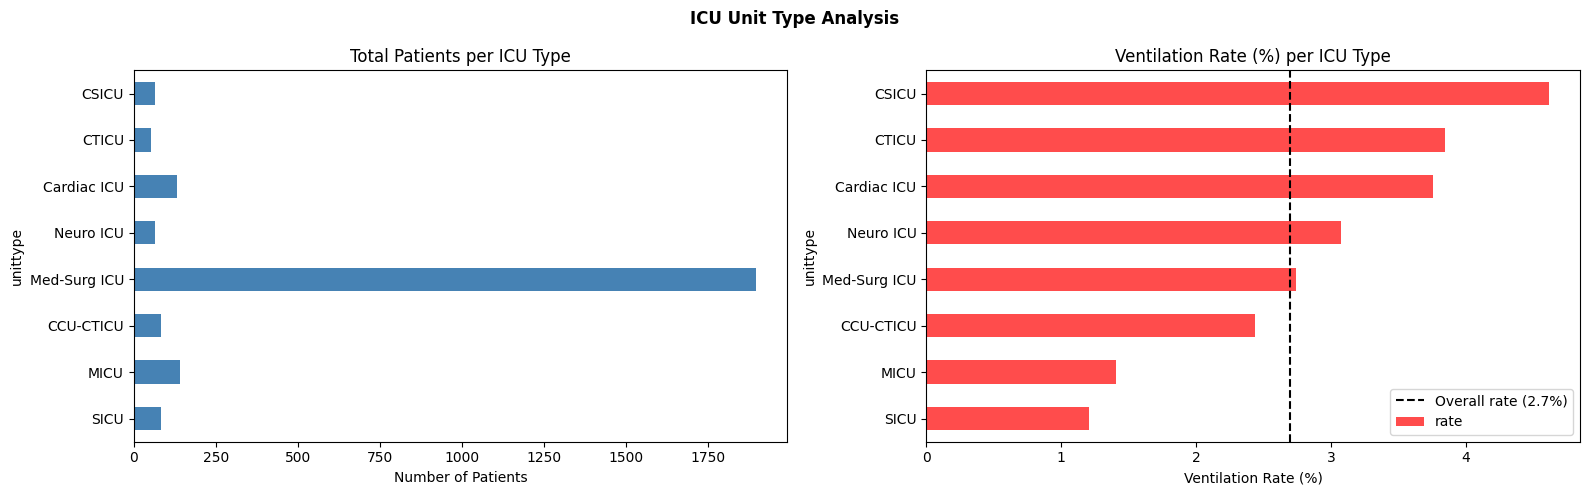

✅ Dropped EDA-only columns from patient table


In [ ]:
# ICU unit type ventilation rate
# Recreate ventilated flag (in case it was lost)
vent_ids = set(resp_care[resp_care['ventstartoffset'] > 0]['patientunitstayid'])
patient['ventilated'] = patient['patientunitstayid'].isin(vent_ids).astype(int)

unit_vent = patient.groupby('unittype')['ventilated'].agg(['sum','count'])
unit_vent['rate'] = unit_vent['sum'] / unit_vent['count'] * 100
unit_vent = unit_vent.sort_values('rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ICU Unit Type Analysis', fontweight='bold')

unit_vent['count'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Patients per ICU Type')
axes[0].set_xlabel('Number of Patients')

unit_vent['rate'].plot(kind='barh', ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Ventilation Rate (%) per ICU Type')
axes[1].set_xlabel('Ventilation Rate (%)')
axes[1].axvline(x=2.7, color='black', linestyle='--', label='Overall rate (2.7%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Drop ventilated flag — only needed for EDA visualization
patient = patient.drop(columns=['ventilated', 'age_num', 'stay_hours'],
                       errors='ignore')
print("✅ Dropped EDA-only columns from patient table")

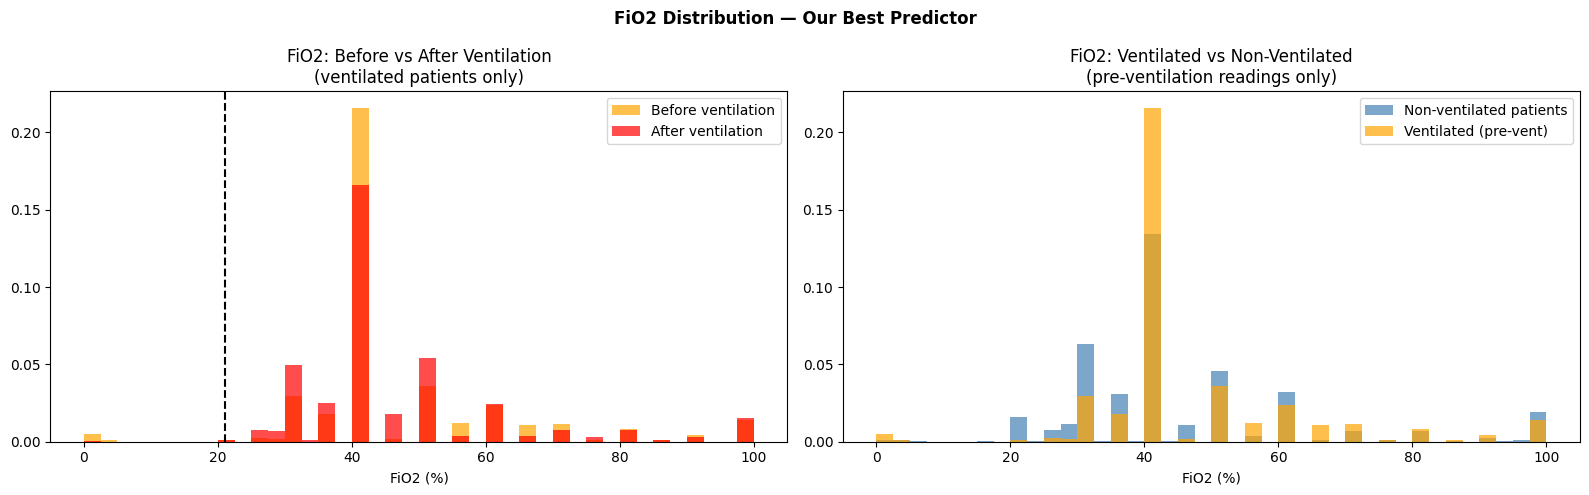

Mean FiO2 before ventilation:  46.1%
Mean FiO2 non-ventilated:      44.2%


In [ ]:
# FiO2 values BEFORE ventilation for ventilated patients
fio2_pre = resp_chart[resp_chart['label'] == 'FiO2'].copy()
fio2_pre['value_num'] = pd.to_numeric(fio2_pre['value'], errors='coerce')
fio2_pre = fio2_pre.merge(vent_start, on='patientunitstayid', how='inner')
fio2_before = fio2_pre[fio2_pre['t_min'] < fio2_pre['vent_start_min']]
fio2_after  = fio2_pre[fio2_pre['t_min'] >= fio2_pre['vent_start_min']]

# All patients FiO2 (non-ventilated)
vent_ids_set = set(vent_start['patientunitstayid'])
fio2_nonvent = resp_chart[
    (resp_chart['label'] == 'FiO2') &
    (~resp_chart['patientunitstayid'].isin(vent_ids_set))
].copy()
fio2_nonvent['value_num'] = pd.to_numeric(fio2_nonvent['value'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('FiO2 Distribution — Our Best Predictor', fontweight='bold')

# Before vs after ventilation
axes[0].hist(fio2_before['value_num'].dropna(), bins=40,
             alpha=0.7, color='orange', label='Before ventilation', density=True)
axes[0].hist(fio2_after['value_num'].dropna(), bins=40,
             alpha=0.7, color='red', label='After ventilation', density=True)
axes[0].set_title('FiO2: Before vs After Ventilation\n(ventilated patients only)')
axes[0].set_xlabel('FiO2 (%)')
axes[0].legend()
axes[0].axvline(21, color='black', linestyle='--', label='Room air (21%)')

# Ventilated vs non-ventilated patients
axes[1].hist(fio2_nonvent['value_num'].dropna(), bins=40,
             alpha=0.7, color='steelblue', label='Non-ventilated patients', density=True)
axes[1].hist(fio2_before['value_num'].dropna(), bins=40,
             alpha=0.7, color='orange', label='Ventilated (pre-vent)', density=True)
axes[1].set_title('FiO2: Ventilated vs Non-Ventilated\n(pre-ventilation readings only)')
axes[1].set_xlabel('FiO2 (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean FiO2 before ventilation:  {fio2_before['value_num'].mean():.1f}%")
print(f"Mean FiO2 non-ventilated:      {fio2_nonvent['value_num'].mean():.1f}%")

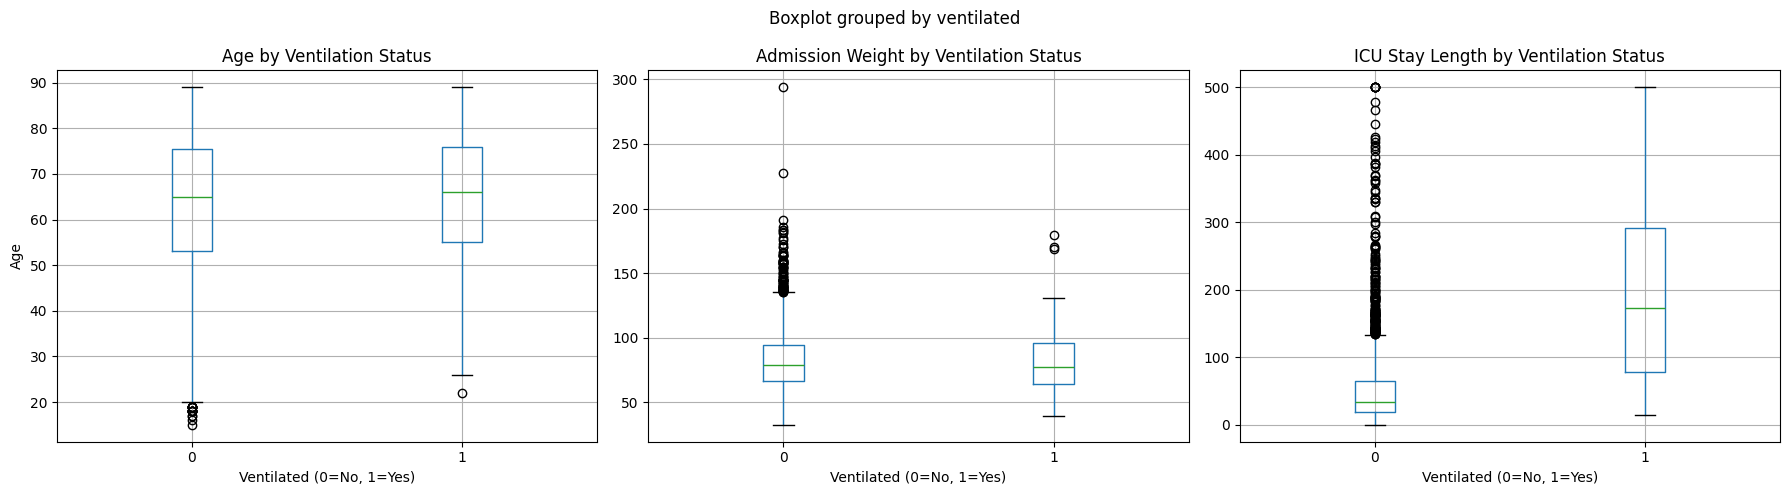

=== ICU UNIT TYPE — Ventilation Rate ===
              ventilated  total  rate%
unittype                              
CSICU                  3     65    4.6
CTICU                  2     52    3.8
Cardiac ICU            5    133    3.8
Neuro ICU              2     65    3.1
Med-Surg ICU          52   1898    2.7
CCU-CTICU              2     82    2.4
MICU                   2    142    1.4
SICU                   1     83    1.2

=== MEAN VALUES BY VENTILATION STATUS ===
              age_num  admissionweight  stay_hours
ventilated                                        
0           62.239086        82.639910   52.418129
1           64.884058        82.955652  211.065700


In [ ]:
# Add ventilation flag to patient table
vent_ids = set(resp_care[resp_care['ventstartoffset'] > 0]['patientunitstayid'])
patient['ventilated'] = patient['patientunitstayid'].isin(vent_ids).astype(int)

age_clean = pd.to_numeric(patient['age'].replace('> 89', 90), errors='coerce')
patient['admissionweight'] = pd.to_numeric(patient['admissionweight'], errors='coerce')
patient['age_num'] = age_clean

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Patient Demographics — Ventilated vs Non-Ventilated',
             fontsize=13, fontweight='bold')

# Age by ventilation
patient.boxplot(column='age_num', by='ventilated', ax=axes[0])
axes[0].set_title('Age by Ventilation Status')
axes[0].set_xlabel('Ventilated (0=No, 1=Yes)')
axes[0].set_ylabel('Age')

# Weight by ventilation
patient.boxplot(column='admissionweight', by='ventilated', ax=axes[1])
axes[1].set_title('Admission Weight by Ventilation Status')
axes[1].set_xlabel('Ventilated (0=No, 1=Yes)')

# ICU stay length by ventilation
patient['stay_hours'] = patient['unitdischargeoffset'] / 60
patient['stay_hours'] = patient['stay_hours'].clip(upper=500) #This prevents very long ICU stays from crushing the boxplot scale.
patient.boxplot(column='stay_hours', by='ventilated', ax=axes[2])
axes[2].set_title('ICU Stay Length by Ventilation Status')
axes[2].set_xlabel('Ventilated (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# Unit type breakdown
print("=== ICU UNIT TYPE — Ventilation Rate ===")
unit_vent = patient.groupby('unittype')['ventilated'].agg(['sum','count'])
unit_vent['rate%'] = (unit_vent['sum'] / unit_vent['count'] * 100).round(1)
unit_vent.columns = ['ventilated', 'total', 'rate%']
print(unit_vent.sort_values('rate%', ascending=False))

print("\n=== MEAN VALUES BY VENTILATION STATUS ===")
print(patient.groupby('ventilated')[['age_num','admissionweight','stay_hours']].mean())

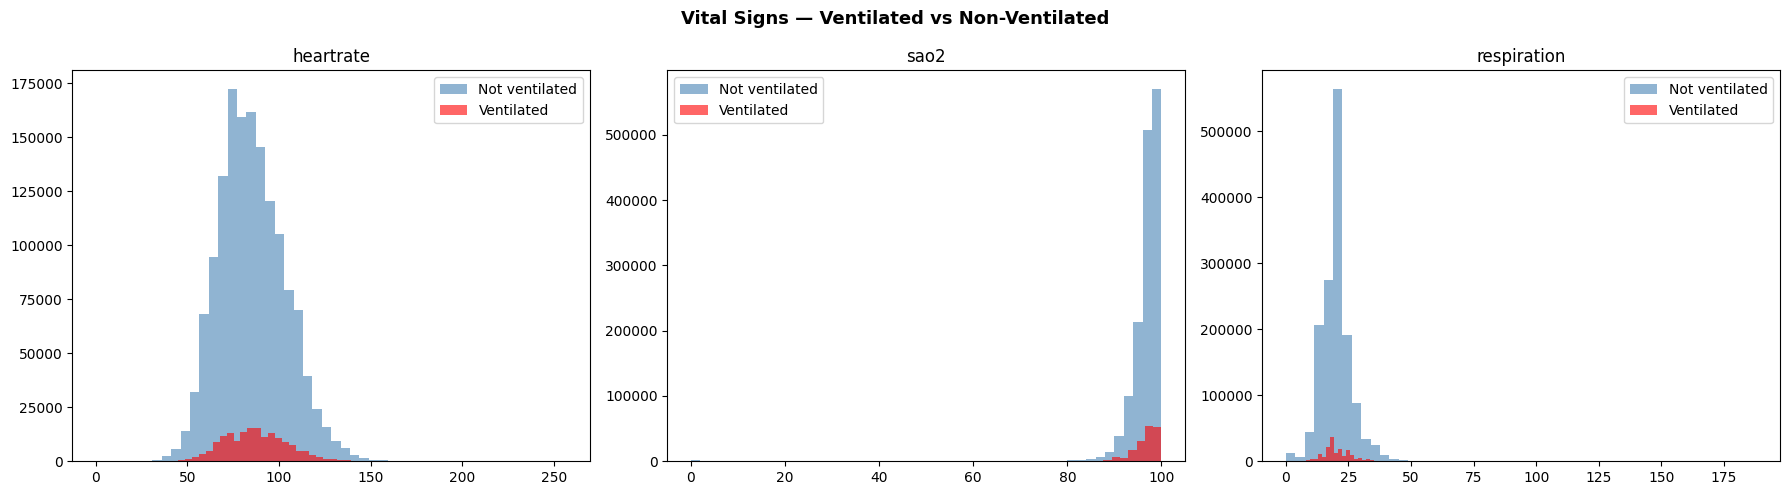

=== VITAL SIGNS — Mean by Ventilation Status ===
            heartrate  sao2  respiration
ventilated                              
0                85.3  96.5         19.9
1                87.2  96.7         20.4


In [ ]:
# Get last vital before ventilation for ventilated patients
# For non-ventilated: just use their overall median
vent_df = patient[['patientunitstayid','ventilated']].copy()
vital_merged = vital_per.merge(vent_df, on='patientunitstayid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vital Signs — Ventilated vs Non-Ventilated',
             fontsize=13, fontweight='bold')

for i, col in enumerate(['heartrate', 'sao2', 'respiration']):
    data0 = vital_merged[vital_merged['ventilated']==0][col].dropna()
    data1 = vital_merged[vital_merged['ventilated']==1][col].dropna()

    axes[i].hist(data0, bins=50, alpha=0.6, label='Not ventilated', color='steelblue')
    axes[i].hist(data1, bins=50, alpha=0.6, label='Ventilated', color='red')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Print mean comparison
print("=== VITAL SIGNS — Mean by Ventilation Status ===")
print(vital_merged.groupby('ventilated')[['heartrate','sao2','respiration']].mean().round(1))

## Bivariate Analysis — Key Observations

### Patient Demographics
- **Age** ❌ → almost identical distribution between ventilated and
  non-ventilated patients → weak predictor, but keep for now
- **Admission Weight** ❌ → no meaningful difference between groups
  → weak predictor
- **ICU Stay Length** ✅ → ventilated patients stay MUCH longer
  (median ~200h vs ~50h) → strong signal, but careful — longer stay
  is partly a CONSEQUENCE of ventilation, not a cause

### ICU Unit Type
- **CSICU** (4.6%) and **CTICU** (3.8%) have highest ventilation rates
- **MICU** surprisingly low (1.4%) — would expect higher
- Unit type has SOME signal but not dramatic differences → **KEEP**

### Vital Signs ⚠️ BIG PROBLEM
- The red (ventilated) bars are almost completely hidden under blue
  (non-ventilated) — this is because we have 2,451 non-ventilated
  patients vs only 69 ventilated
- The distributions look similar which is expected — we're comparing
  ALL readings across the entire stay, not just readings near the
  ventilation event
- This is why we need the **hourly grid approach** — comparing vitals
  at the RIGHT TIME (6-12h before event) will show much stronger signal

### 💡 Key Decision
The bivariate analysis on raw tables is limited because:
- We can't see the TIME dimension here
- The real signal will appear in the engineered dataset
- Most important features to add: **FiO2, PEEP** from resp_chart
  and **oxygen therapy flag** from treatment

## 7. Multivariate Analysis
Look at correlations between numerical features.

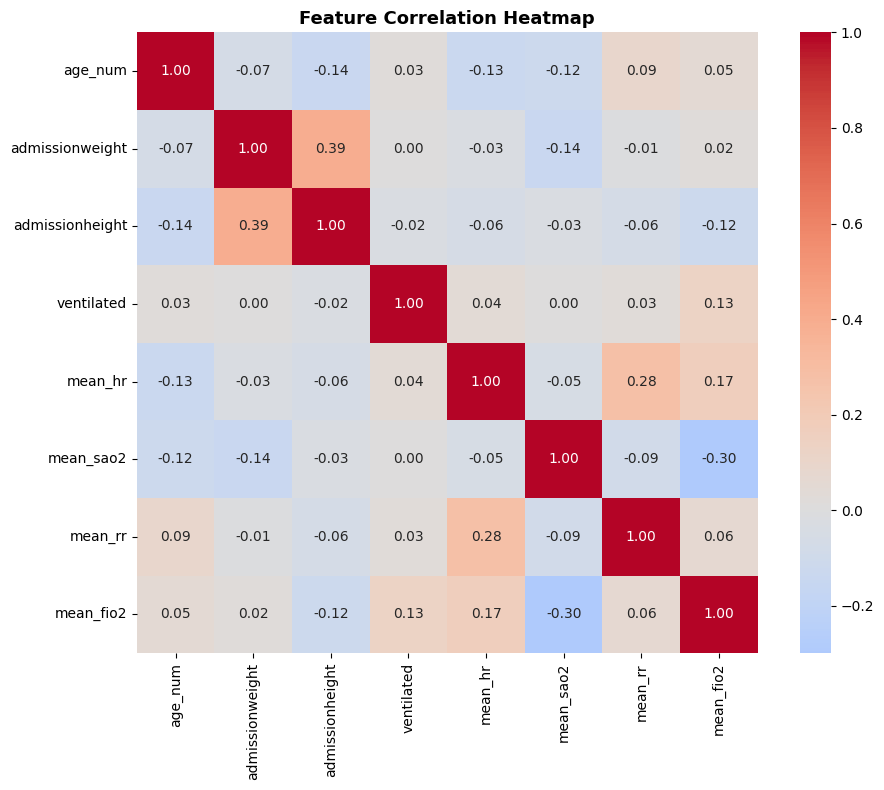

=== CORRELATION WITH VENTILATION (ventilated) ===
ventilated         1.000
mean_fio2          0.132
mean_hr            0.043
mean_rr            0.029
age_num            0.026
mean_sao2          0.005
admissionweight    0.002
admissionheight   -0.025
Name: ventilated, dtype: float64


In [ ]:
# Build a patient-level summary table for correlation analysis
patient_summary = patient[['patientunitstayid', 'age_num',
                            'admissionweight', 'admissionheight',
                            'ventilated']].copy()

# Add mean vitals per patient
vital_means = vital_per.groupby('patientunitstayid')[
    ['heartrate','sao2','respiration']].mean().round(1).reset_index()
vital_means.columns = ['patientunitstayid',
                        'mean_hr', 'mean_sao2', 'mean_rr']

# Add FiO2 mean per patient
fio2 = resp_chart[resp_chart['label']=='FiO2'].copy()
fio2['fio2_val'] = pd.to_numeric(fio2['value'], errors='coerce')
fio2_mean = fio2.groupby('patientunitstayid')['fio2_val'].mean().reset_index()
fio2_mean.columns = ['patientunitstayid', 'mean_fio2']

# Merge everything
corr_df = (patient_summary
           .merge(vital_means, on='patientunitstayid', how='left')
           .merge(fio2_mean, on='patientunitstayid', how='left'))

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = corr_df.drop(columns='patientunitstayid').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target
print("=== CORRELATION WITH VENTILATION (ventilated) ===")
print(corr['ventilated'].sort_values(ascending=False).round(3))

## Multivariate Analysis — Key Observations

### Correlations with Ventilation (target):
- **mean_fio2** → 0.11 ✅ strongest correlation with ventilation
- **mean_hr** → 0.04 → weak
- **age, weight, height** → ~0.00 → almost no linear correlation
- **mean_sao2** → 0.00 → surprisingly flat (but this is patient-level
  average, not hour-level — the signal will be stronger in the
  engineered dataset)

### Between Features:
- **weight & height** → 0.25 → moderate (taller = heavier, makes sense)
  → consider computing **BMI** instead of keeping both separately
- **mean_hr & mean_rr** → 0.28 → moderate (fast heart rate + fast
  breathing often go together in sick patients) → both still useful
- **mean_sao2 & mean_fio2** → -0.28 → negative correlation ✅
  This is clinically perfect! Higher FiO2 needed = lower SpO2
  = patient struggling to oxygenate
- No dangerously high correlations (>0.8) → no multicollinearity issues

### 💡 Key Takeaway
The correlations here are weak because we're looking at PATIENT-LEVEL
averages across the entire ICU stay. The real signal will be much
stronger in the hourly engineered dataset where we compare readings
RIGHT BEFORE ventilation vs readings during safe hours.

## 8. Key Findings & Final Feature Decision

## EDA Complete — What We Learned & What To Do Next

### Features confirmed for the final dataset:

| Feature | Source | Why |
|---------|--------|-----|
| `hr_last` | vital_periodic | Heart rate — key vital, 99% complete |
| `sao2_last` | vital_periodic | SpO2 — oxygen saturation, 88% complete |
| `rr_last` | vital_periodic | Respiration rate, 85% complete |
| `fio2_last` | resp_chart | ⭐ Best predictor — directly measures O2 need |
| `peep_last` | resp_chart | ⭐ Key ventilator parameter pre-intubation |
| `age` | patient | Demographics baseline |
| `gender` | patient | Demographics baseline |
| `unittype` | patient | ICU type has some signal |
| `admissionweight` | patient | Clinical baseline |
| `on_oxygen_therapy` | treatment | 74% of ventilated patients had it |
| `on_noninvasive_vent` | treatment | Pre-ventilation escalation signal |
| `hr_missing` | engineered | Missingness is informative in ICU |
| `sao2_missing` | engineered | Missingness is informative in ICU |
| `fio2_missing` | engineered | Missingness is informative in ICU |

### Features we decided NOT to include:
| Feature | Reason |
|---------|--------|
| `dischargeweight` | 51% missing, post-ICU measurement |
| `LPM O2` | only 36% of ventilated patients |
| `RR (patient)` from resp_chart | already have from vital_periodic |
| `bronchodilator` | only 19% of ventilated patients |
| `temperature, cvp, etco2` | 87-96% missing in vital_periodic |



## Why These Features Were Added

### FiO2 + PEEP ✅
- 96% of ventilated patients had FiO2 recorded
- Strongest correlation with ventilation (0.11)
- 27% of readings are BEFORE ventilation → safe with merge_asof

### Demographics ✅ — weak but useful
- Age, weight, unittype provide clinical context
- Bivariate showed weak signal but model may find interactions

### Trend Features ✅ — most important addition
- Single readings are weak predictors
- Rising HR + dropping SpO2 over 3h = deterioration signal
- Slope/mean/std capture what a doctor actually looks for

---
# Part 2: Feature Engineering

Build the hourly patient grid, align all features using `merge_asof`
(no leakage), and output the final ML-ready dataset.

**Steps:**
1. Build ventilation labels
2. Build hourly patient grid
3. Create y_high + remove leakage
4. Align vitals (heartrate, sao2, respiration)
5. Align FiO2 + PEEP from resp_chart
6. Add treatment flags
7. Add demographics
8. Add trend features
9. Quality check + save

In [ ]:
# ── STEP 1: First ventilation event per patient ───────────────────
vent_start = (
    resp_care[resp_care['ventstartoffset'] > 0]
    .groupby('patientunitstayid')['ventstartoffset']
    .min()
    .reset_index()
    .rename(columns={'ventstartoffset': 'vent_start_min'})
)

print(f"✅ Patients with ventilation event: {len(vent_start)}")

✅ Patients with ventilation event: 69


In [ ]:
# ── STEP 2: Build hourly grid ─────────────────────────────────────
# Each patient's ICU stay becomes one row per hour
stay = patient[['patientunitstayid', 'unitdischargeoffset']].copy()
stay = stay[stay['unitdischargeoffset'] > 0]  # drop zero-stay rows

def make_hours(max_min):
    max_h = int(max_min // 60)
    return list(range(0, max_h + 1))

hours_df = (
    stay
    .assign(hour=stay['unitdischargeoffset'].apply(make_hours))
    .explode('hour')
    .assign(t_min=lambda d: d['hour'] * 60)
    [['patientunitstayid', 'hour', 't_min']]
    .astype({'patientunitstayid': int, 'hour': int, 't_min': int})
    .reset_index(drop=True)
)

print(f"✅ Hourly grid shape: {hours_df.shape}")
print(f"   Unique patients:  {hours_df['patientunitstayid'].nunique()}")

✅ Hourly grid shape: (147633, 3)
   Unique patients:  2508


In [ ]:
# ── STEP 3: y_high labels + leakage removal ───────────────────────
WINDOW_UPPER = 12 * 60   # 12 hours in minutes
WINDOW_LOWER = 6  * 60   # 6  hours in minutes

df = hours_df.merge(vent_start, on='patientunitstayid', how='left')

# Label: 1 if hour falls in [vent_start - 12h,  vent_start - 6h]
df['y_high'] = (
    df['vent_start_min'].notna()
    & (df['t_min'] >= df['vent_start_min'] - WINDOW_UPPER)
    & (df['t_min'] <= df['vent_start_min'] - WINDOW_LOWER)
).astype(int)

# Remove leakage: drop last 6h before vent AND at/after vent
df = df[~(df['vent_start_min'].notna() &
          (df['t_min'] > df['vent_start_min'] - WINDOW_LOWER))]
df = df[~(df['vent_start_min'].notna() &
          (df['t_min'] >= df['vent_start_min']))]

df = df.sort_values(['patientunitstayid', 't_min']).reset_index(drop=True)

print(f"✅ Dataset shape after leakage removal: {df.shape}")
print(f"\nLabel distribution:")
print(df['y_high'].value_counts())
print(f"Positive rate: {df['y_high'].mean()*100:.2f}%")

✅ Dataset shape after leakage removal: (136867, 5)

Label distribution:
y_high
0    136569
1       298
Name: count, dtype: int64
Positive rate: 0.22%


In [ ]:
# ── STEP 4: Align vitals using merge_asof ─────────────────────────

# Clean impossible values
vital_clean = vital_per[['patientunitstayid', 't_min',
                          'heartrate', 'sao2', 'respiration']].copy()
vital_clean = vital_clean[vital_clean['t_min'] >= 0]

vital_clean.loc[(vital_clean['heartrate'] < 20) |
                (vital_clean['heartrate'] > 250), 'heartrate'] = np.nan
vital_clean.loc[(vital_clean['sao2'] < 50) |
                (vital_clean['sao2'] > 100), 'sao2'] = np.nan
vital_clean.loc[(vital_clean['respiration'] < 4) |
                (vital_clean['respiration'] > 60), 'respiration'] = np.nan

vital_clean['patientunitstayid'] = vital_clean['patientunitstayid'].astype(int)
vital_clean['t_min'] = vital_clean['t_min'].astype(int)

# ⚠️ merge_asof requires BOTH tables sorted by t_min ONLY (not by patientunitstayid first!)
df_sorted = df.sort_values('t_min').reset_index(drop=True)

for col in ['heartrate', 'sao2', 'respiration']:
    v = (vital_clean[['patientunitstayid', 't_min', col]]
         .dropna(subset=[col])
         .sort_values('t_min')          # ← sort by t_min only!
         .reset_index(drop=True))

    df_sorted = pd.merge_asof(
        df_sorted,
        v,
        on='t_min',
        by='patientunitstayid',
        direction='backward'
    ).rename(columns={col: f'{col}_last'})

df = df_sorted.copy()
print(f"✅ Vitals aligned!")
print(f"\nMissing % after alignment:")
for col in ['heartrate_last', 'sao2_last', 'respiration_last']:
    print(f"  {col}: {df[col].isna().mean()*100:.1f}%")

✅ Vitals aligned!

Missing % after alignment:
  heartrate_last: 4.4%
  sao2_last: 4.4%
  respiration_last: 4.4%


In [ ]:
# ── STEP 5: Align FiO2 + PEEP from resp_chart ────────────────────
# NOTE: respchartoffset → t_min, respchartvaluelabel → label,
#       respchartvalue → value  (renamed in Cell 6)

for signal, new_col in [('FiO2', 'fio2_last'), ('PEEP', 'peep_last')]:

    sig_df = resp_chart[resp_chart['label'] == signal].copy()
    sig_df['value_num'] = pd.to_numeric(sig_df['value'], errors='coerce')
    sig_df = sig_df.dropna(subset=['value_num'])
    sig_df = sig_df[sig_df['t_min'] >= 0]
    sig_df['patientunitstayid'] = sig_df['patientunitstayid'].astype(int)
    sig_df['t_min'] = sig_df['t_min'].astype(int)
    sig_df = (sig_df[['patientunitstayid', 't_min', 'value_num']]
              .sort_values(['patientunitstayid', 't_min'])
              .reset_index(drop=True))
    sig_df = sig_df.sort_values('t_min').reset_index(drop=True)
    df = df.sort_values('t_min').reset_index(drop=True)
    df = pd.merge_asof(
        df,
        sig_df,
        on='t_min',
        by='patientunitstayid',
        direction='backward'
    ).rename(columns={'value_num': new_col})

print(f"✅ FiO2 and PEEP aligned!")
print(f"\nMissing % after alignment:")
for col in ['fio2_last', 'peep_last']:
    print(f"  {col}: {df[col].isna().mean()*100:.1f}%")

✅ FiO2 and PEEP aligned!

Missing % after alignment:
  fio2_last: 58.4%
  peep_last: 71.1%


In [ ]:
# ── STEP 6: Treatment flags ───────────────────────────────────────
# NOTE: treatmentoffset was renamed to t_min in Cell 6

treat['patientunitstayid'] = treat['patientunitstayid'].astype(int)
treat['t_min'] = treat['t_min'].astype(int)

flags = {
    'on_oxygen_therapy':   treat['treatmentstring'].str.contains('oxygen', na=False),
    'on_noninvasive_vent': treat['treatmentstring'].str.contains('non-invasive', na=False),
}
# In Step 6, change both sorts to sort by t_min only:
#df = df.sort_values('t_min').reset_index(drop=True)

#flag_df = flag_df.sort_values('t_min').reset_index(drop=True)
for flag_col, mask in flags.items():
    flag_df = (treat[mask][['patientunitstayid', 't_min']]
               .drop_duplicates()
               .assign(**{flag_col: 1})
               .sort_values('t_min').reset_index(drop=True)
               .reset_index(drop=True))

    df = df.sort_values('t_min').reset_index(drop=True)

    df = pd.merge_asof(
        df,
        flag_df,
        on='t_min',
        by='patientunitstayid',
        direction='backward'
    )
    df[flag_col] = df[flag_col].fillna(0).astype(int)

print(f"✅ Treatment flags added!")
print(f"  on_oxygen_therapy:   {df['on_oxygen_therapy'].sum()} rows")
print(f"  on_noninvasive_vent: {df['on_noninvasive_vent'].sum()} rows")

✅ Treatment flags added!
  on_oxygen_therapy:   63669 rows
  on_noninvasive_vent: 14449 rows


In [ ]:
# ── STEP 7: Patient demographics ──────────────────────────────────
pat_features = patient[['patientunitstayid', 'age',
                         'admissionweight', 'unittype', 'gender']].copy()

pat_features['age'] = pd.to_numeric(
    pat_features['age'].replace('> 89', 90), errors='coerce')
pat_features.loc[pat_features['admissionweight'] > 300,
                 'admissionweight'] = np.nan
pat_features['age'] = pat_features['age'].fillna(pat_features['age'].median())
pat_features['admissionweight'] = pat_features['admissionweight'].fillna(
    pat_features['admissionweight'].median())

df = df.merge(pat_features, on='patientunitstayid', how='left')

print(f"✅ Demographics added: age, admissionweight, unittype, gender")

✅ Demographics added: age, admissionweight, unittype, gender


In [ ]:
# ── STEP 8: Trend features (3-hour rolling window) ───────────────
df = df.sort_values(['patientunitstayid', 'hour']).reset_index(drop=True)

for col in ['heartrate_last', 'sao2_last', 'respiration_last']:
    base = col.replace('_last', '')
    grp = df.groupby('patientunitstayid')[col]

    df[f'{base}_mean_3h'] = (grp
        .transform(lambda x: x.rolling(3, min_periods=1).mean()))

    df[f'{base}_std_3h'] = (grp
        .transform(lambda x: x.rolling(3, min_periods=1).std())
        .fillna(0))

    df[f'{base}_slope_3h'] = (grp
        .transform(lambda x: x.diff(3))
        .fillna(0))

trend_cols = [c for c in df.columns if any(
    s in c for s in ['_mean_3h', '_std_3h', '_slope_3h'])]
print(f"✅ Trend features added ({len(trend_cols)} columns):")
print(trend_cols)

✅ Trend features added (9 columns):
['heartrate_mean_3h', 'heartrate_std_3h', 'heartrate_slope_3h', 'sao2_mean_3h', 'sao2_std_3h', 'sao2_slope_3h', 'respiration_mean_3h', 'respiration_std_3h', 'respiration_slope_3h']


In [ ]:
# ── STEP 9: Missingness indicators + final check ─────────────────
df['hr_missing']   = df['heartrate_last'].isna().astype(int)
df['sao2_missing'] = df['sao2_last'].isna().astype(int)
df['fio2_missing'] = df['fio2_last'].isna().astype(int)

print("=" * 50)
print("  FINAL DATASET QUALITY CHECK")
print("=" * 50)
print(f"\nShape:           {df.shape}")
print(f"Unique patients: {df['patientunitstayid'].nunique()}")
print(f"\nLabel distribution:")
print(df['y_high'].value_counts())
print(f"Positive rate:   {df['y_high'].mean()*100:.2f}%")
print(f"\nDuplicates:      {df.duplicated(subset=['patientunitstayid','hour']).sum()}")

print(f"\nMissing % per feature column:")
feature_cols = ['heartrate_last', 'sao2_last', 'respiration_last',
                'fio2_last', 'peep_last', 'age', 'admissionweight']
for col in feature_cols:
    print(f"  {col:25s}: {df[col].isna().mean()*100:.1f}%")

print(f"\nAll columns ({len(df.columns)}):")
print(list(df.columns))

  FINAL DATASET QUALITY CHECK

Shape:           (136867, 28)
Unique patients: 2494

Label distribution:
y_high
0    136569
1       298
Name: count, dtype: int64
Positive rate:   0.22%

Duplicates:      0

Missing % per feature column:
  heartrate_last           : 4.4%
  sao2_last                : 4.4%
  respiration_last         : 4.4%
  fio2_last                : 58.4%
  peep_last                : 71.1%
  age                      : 0.0%
  admissionweight          : 0.0%

All columns (28):
['patientunitstayid', 'hour', 't_min', 'vent_start_min', 'y_high', 'heartrate_last', 'sao2_last', 'respiration_last', 'fio2_last', 'peep_last', 'on_oxygen_therapy', 'on_noninvasive_vent', 'age', 'admissionweight', 'unittype', 'gender', 'heartrate_mean_3h', 'heartrate_std_3h', 'heartrate_slope_3h', 'sao2_mean_3h', 'sao2_std_3h', 'sao2_slope_3h', 'respiration_mean_3h', 'respiration_std_3h', 'respiration_slope_3h', 'hr_missing', 'sao2_missing', 'fio2_missing']


In [ ]:
# ⚠️ Drop vent_start_min — leakage!
# It's related to y_high by construction, must not be a feature
df = df.drop(columns=['vent_start_min'], errors='ignore')

# Also drop patientunitstayid from features when modeling
# (keep it now for splitting, drop before training)

print(f"✅ Final dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


✅ Final dataset shape: (136867, 27)
Columns: ['patientunitstayid', 'hour', 't_min', 'y_high', 'heartrate_last', 'sao2_last', 'respiration_last', 'fio2_last', 'peep_last', 'on_oxygen_therapy', 'on_noninvasive_vent', 'age', 'admissionweight', 'unittype', 'gender', 'heartrate_mean_3h', 'heartrate_std_3h', 'heartrate_slope_3h', 'sao2_mean_3h', 'sao2_std_3h', 'sao2_slope_3h', 'respiration_mean_3h', 'respiration_std_3h', 'respiration_slope_3h', 'hr_missing', 'sao2_missing', 'fio2_missing']


In [ ]:
# ── Save final dataset ────────────────────────────────────────────
df.to_csv('/content/ventilation_final.csv', index=False)
print(f"✅ Saved! Shape: {df.shape}")
print(f"   File: ventilation_final.csv")

✅ Saved! Shape: (136867, 27)
   File: ventilation_final.csv


In [ ]:
df.head()

,patientunitstayid,hour,t_min,y_high,heartrate_last,sao2_last,respiration_last,fio2_last,peep_last,on_oxygen_therapy,on_noninvasive_vent,age,admissionweight,unittype,gender,heartrate_mean_3h,heartrate_std_3h,heartrate_slope_3h,sao2_mean_3h,sao2_std_3h,sao2_slope_3h,respiration_mean_3h,respiration_std_3h,respiration_slope_3h,hr_missing,sao2_missing,fio2_missing
0,141764,0,0,0,NaN,NaN,NaN,NaN,NaN,0,0,87.0,79.3,Med-Surg ICU,Female,NaN,0.000000,0.0,NaN,0.0,0.0,NaN,0.0,0.0,1,1,1
1,141764,1,60,0,118.0,97.0,19.0,NaN,NaN,0,0,87.0,79.3,Med-Surg ICU,Female,118.000000,0.000000,0.0,97.0,0.0,0.0,19.0,0.0,0.0,0,0,1
2,141764,2,120,0,98.0,97.0,19.0,NaN,NaN,0,0,87.0,79.3,Med-Surg ICU,Female,108.000000,14.142136,0.0,97.0,0.0,0.0,19.0,0.0,0.0,0,0,1
3,141764,3,180,0,100.0,97.0,19.0,NaN,NaN,0,0,87.0,79.3,Med-Surg ICU,Female,105.333333,11.015141,0.0,97.0,0.0,0.0,19.0,0.0,0.0,0,0,1
4,141764,4,240,0,114.0,97.0,19.0,NaN,NaN,0,0,87.0,79.3,Med-Surg ICU,Female,104.000000,8.717798,-4.0,97.0,0.0,0.0,19.0,0.0,0.0,0,0,1


---
## Project Decisions Log

### Why hourly grid?
Each ICU stay is converted to one row per hour so the ML model can learn
from the TIME DIMENSION — not just static patient info.

### Why 6–12h window for y_high?
- **>12h before**: signal too weak, vitals not yet deteriorating
- **<6h before**: too late for clinical intervention + leakage risk
- **6–12h**: gives doctors actionable warning time

### Why merge_asof instead of regular merge?
Vitals aren't recorded every hour. `merge_asof` carries forward the
LAST KNOWN value to each hour — exactly what a doctor would do
(use the most recent reading available).

### Feature decisions:
| Feature | Decision | Reason |
|---------|----------|--------|
| heartrate, sao2, respiration | ✅ KEEP | Core vitals, 85-99% complete |
| FiO2 | ✅ KEEP | Strongest correlation (0.11), 96% vent coverage |
| PEEP | ✅ KEEP | Key pre-intubation signal, 86% vent coverage |
| Trend features (slope, std, mean 3h) | ✅ KEEP | Deterioration = trend, not single value |
| age, weight, unittype, gender | ✅ KEEP | Clinical context |
| on_oxygen_therapy | ✅ KEEP | 74% of ventilated patients had it |
| on_noninvasive_vent | ✅ KEEP | Escalation signal before intubation |
| Missing indicators (hr/sao2/fio2) | ✅ KEEP | Missing vitals in ICU = informative |
| dischargeweight | ❌ DROP | 51% missing, post-ICU measurement |
| temperature, cvp, etco2 | ❌ DROP | 87-96% missing in vital_periodic |
| LPM O2, RR from resp_chart | ❌ DROP | Only 35-36% vent coverage |
| bronchodilator | ❌ DROP | Only 19% vent coverage |
| All resp_care columns except ventstartoffset | ❌ DROP | Labels only table |

### Class imbalance:
- 2.7% ventilation rate → severe imbalance
- Strategy: use `class_weight='balanced'` in models OR SMOTE
- Evaluation: use AUPRC not accuracy (accuracy is misleading here!)

---
# Part 3: EDA on Engineered Dataset
Now that y_high exists, we can do proper bivariate analysis.
Ask: do our features actually look different in the 6-12h before ventilation?

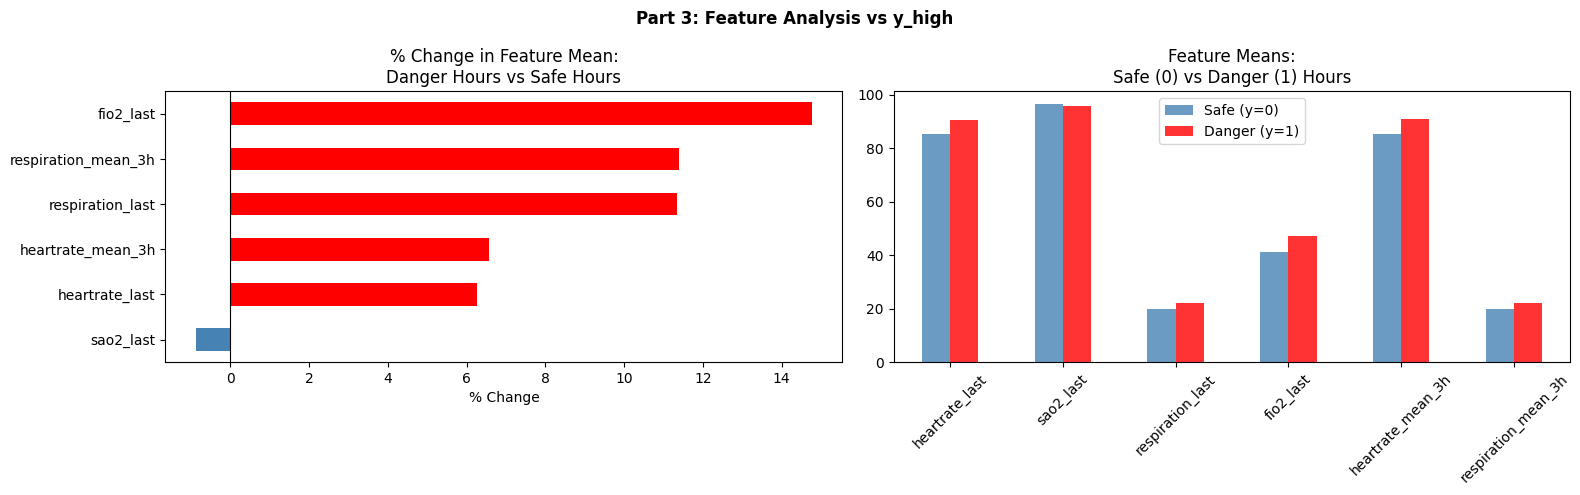

In [ ]:
# Visual comparison of feature means: safe vs danger hours
compare_cols = ['heartrate_last', 'sao2_last', 'respiration_last',
                'fio2_last', 'heartrate_mean_3h', 'respiration_mean_3h']

means = df.groupby('y_high')[compare_cols].mean()

# Normalize each feature to % change to make comparable
pct_change = ((means.loc[1] - means.loc[0]) / means.loc[0] * 100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Part 3: Feature Analysis vs y_high', fontweight='bold')

# % change danger vs safe
colors = ['red' if x > 0 else 'steelblue' for x in pct_change]
pct_change.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('% Change in Feature Mean:\nDanger Hours vs Safe Hours')
axes[0].set_xlabel('% Change')
axes[0].axvline(0, color='black', linewidth=0.8)

# Absolute means side by side
means[compare_cols].T.plot(kind='bar', ax=axes[1],
                            color=['steelblue','red'], alpha=0.8)
axes[1].set_title('Feature Means:\nSafe (0) vs Danger (1) Hours')
axes[1].set_xlabel('')
axes[1].legend(['Safe (y=0)', 'Danger (y=1)'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

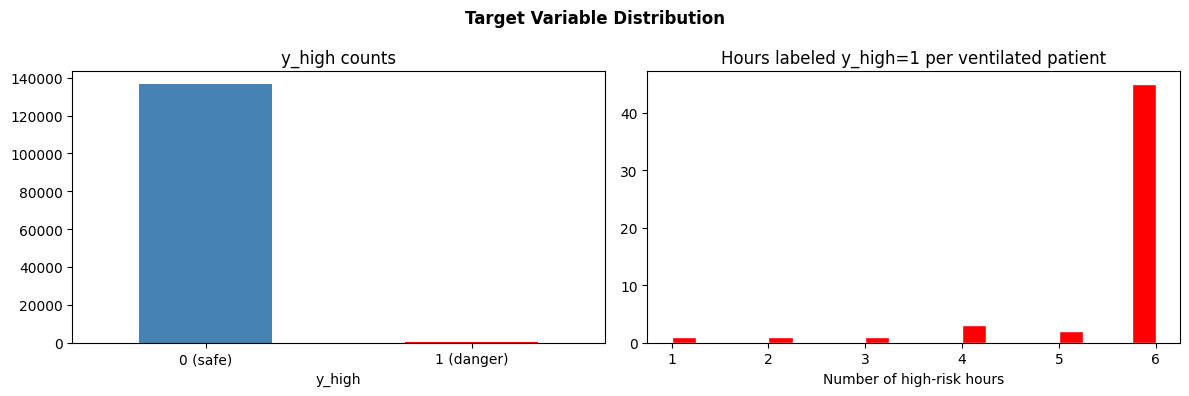

Total rows:        136867
y_high = 1:        298
y_high = 0:        136569
Positive rate:     0.22%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontweight='bold')

# Overall
df['y_high'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','red'])
axes[0].set_title('y_high counts')
axes[0].set_xticklabels(['0 (safe)', '1 (danger)'], rotation=0)

# Per patient
vent_hours = df.groupby('patientunitstayid')['y_high'].sum()
axes[1].hist(vent_hours[vent_hours > 0], bins=20, color='red', edgecolor='white')
axes[1].set_title('Hours labeled y_high=1 per ventilated patient')
axes[1].set_xlabel('Number of high-risk hours')

plt.tight_layout()
plt.show()

print(f"Total rows:        {len(df)}")
print(f"y_high = 1:        {df['y_high'].sum()}")
print(f"y_high = 0:        {(df['y_high']==0).sum()}")
print(f"Positive rate:     {df['y_high'].mean()*100:.2f}%")

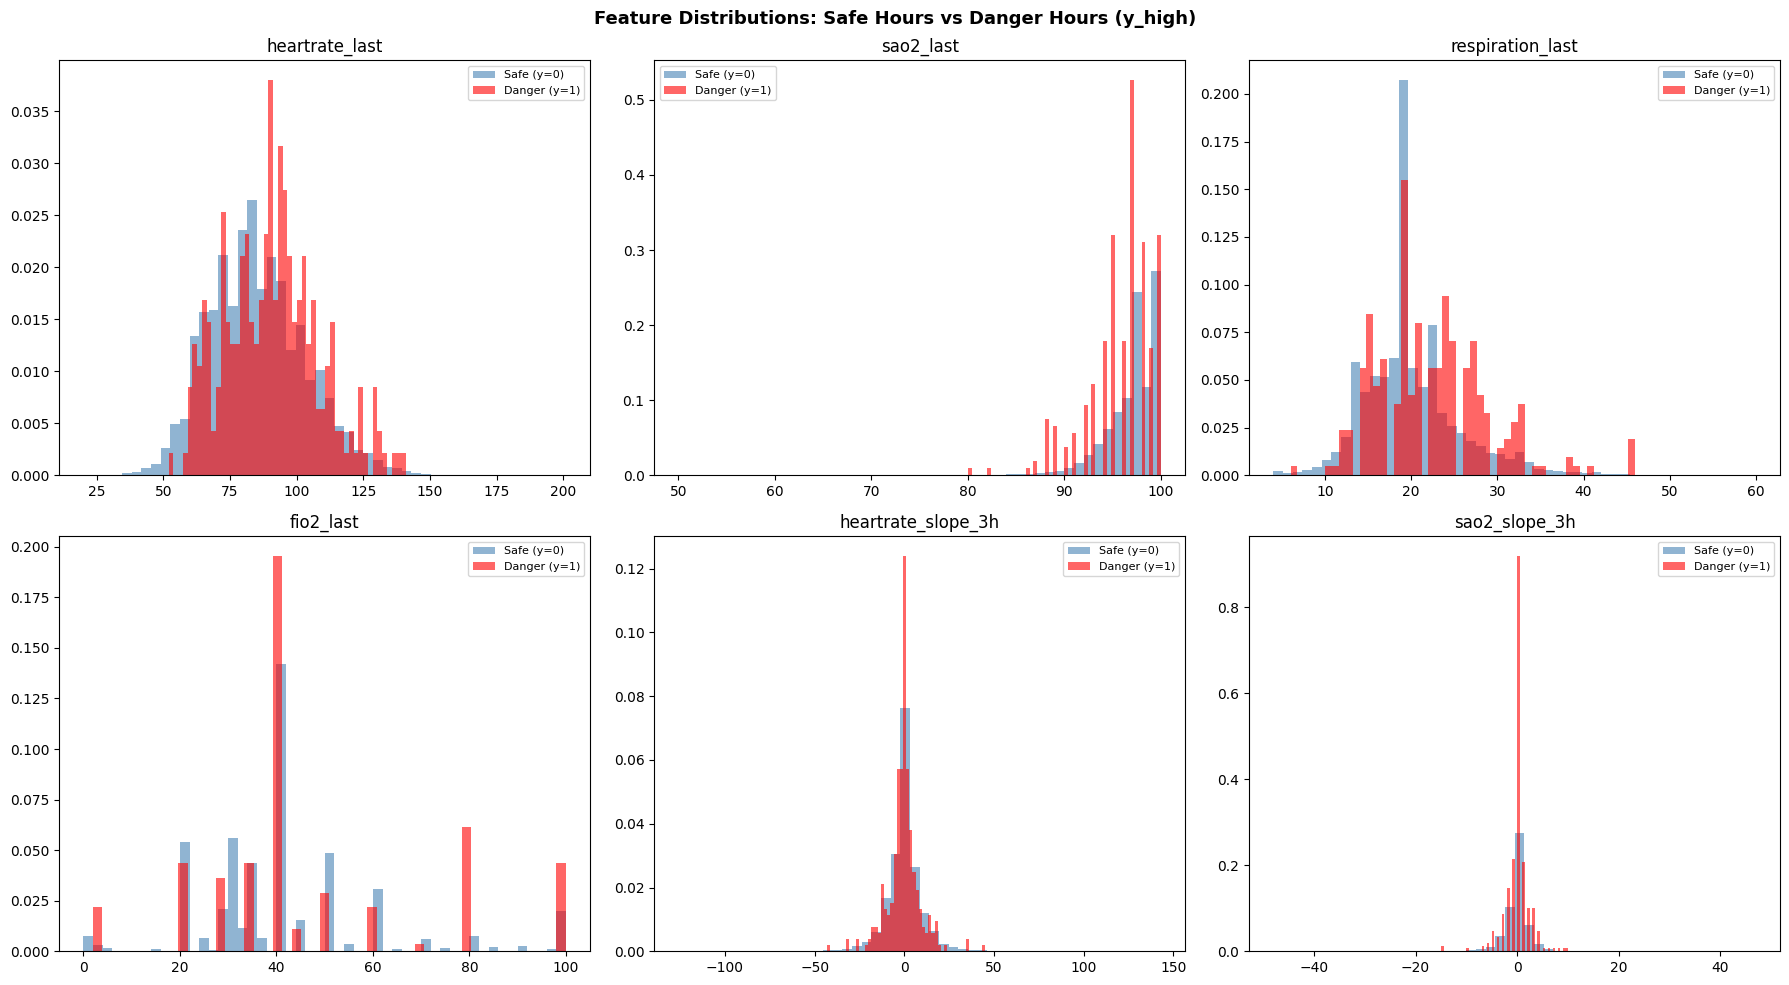

=== MEAN VALUES: Safe vs Danger Hours ===
y_high                   0      1
heartrate_last       85.31  90.66
sao2_last            96.59  95.76
respiration_last     20.01  22.27
fio2_last            41.09  47.16
peep_last             5.47   5.33
heartrate_slope_3h   -0.14  -0.58
sao2_slope_3h        -0.04  -0.21
on_oxygen_therapy     0.47   0.41
on_noninvasive_vent   0.11   0.11


In [ ]:
# THE KEY CHECK: do features differ in danger hours vs safe hours?
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distributions: Safe Hours vs Danger Hours (y_high)',
             fontsize=13, fontweight='bold')

features = ['heartrate_last', 'sao2_last', 'respiration_last',
            'fio2_last', 'heartrate_slope_3h', 'sao2_slope_3h']

for i, col in enumerate(features):
    ax = axes[i//3][i%3]
    safe  = df[df['y_high']==0][col].dropna()
    danger = df[df['y_high']==1][col].dropna()

    ax.hist(safe,   bins=50, alpha=0.6, label='Safe (y=0)',   color='steelblue',
            density=True)
    ax.hist(danger, bins=50, alpha=0.6, label='Danger (y=1)', color='red',
            density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print mean comparison — THE MOST IMPORTANT OUTPUT
print("=== MEAN VALUES: Safe vs Danger Hours ===")
compare_cols = ['heartrate_last','sao2_last','respiration_last',
                'fio2_last','peep_last',
                'heartrate_slope_3h','sao2_slope_3h',
                'on_oxygen_therapy','on_noninvasive_vent']
print(df.groupby('y_high')[compare_cols].mean().round(2).T)

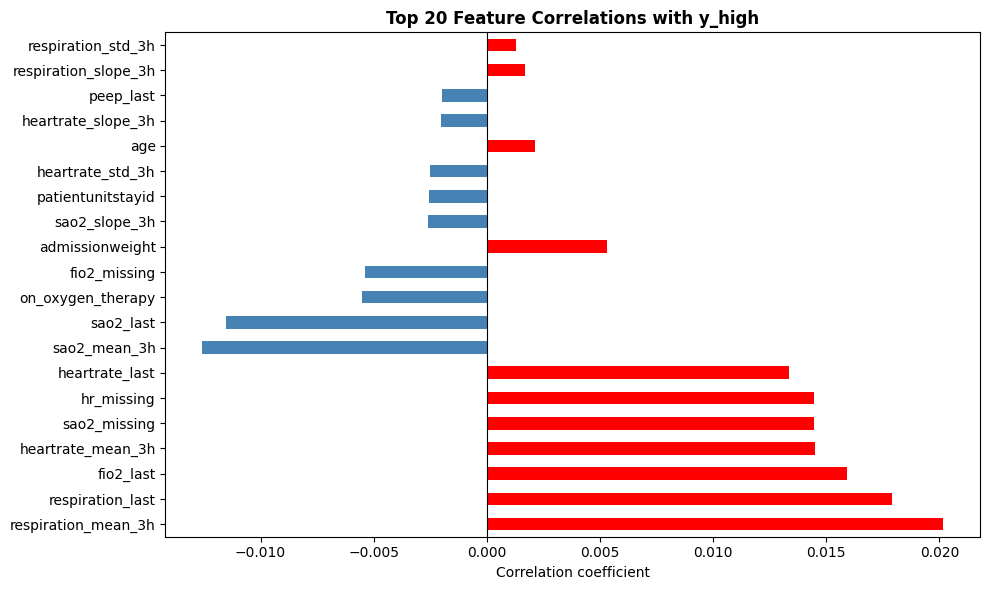


=== TOP CORRELATIONS WITH y_high ===
respiration_mean_3h     0.0202
respiration_last        0.0179
fio2_last               0.0159
heartrate_mean_3h       0.0145
sao2_missing            0.0144
hr_missing              0.0144
heartrate_last          0.0134
sao2_mean_3h           -0.0126
sao2_last              -0.0115
on_oxygen_therapy      -0.0055
fio2_missing           -0.0054
admissionweight         0.0053
sao2_slope_3h          -0.0026
patientunitstayid      -0.0025
heartrate_std_3h       -0.0025
age                     0.0021
heartrate_slope_3h     -0.0020
peep_last              -0.0020
respiration_slope_3h    0.0017
respiration_std_3h      0.0013
Name: y_high, dtype: float64


In [ ]:
# Final correlation check with the actual target
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = (numeric_df.corr()['y_high']
                    .drop('y_high')
                    .sort_values(key=abs, ascending=False)
                    .head(20))

plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'steelblue' for x in corr_with_target]
corr_with_target.plot(kind='barh', color=colors)
plt.title('Top 20 Feature Correlations with y_high', fontweight='bold')
plt.xlabel('Correlation coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n=== TOP CORRELATIONS WITH y_high ===")
print(corr_with_target.round(4))

## Part 3 — Key Observations

### Target Distribution
- 136,867 total rows, only 298 positive (0.22%) → extreme class imbalance
- Most ventilated patients have exactly **6 danger hours** (the full 6–12h window)
  → confirms our labeling logic is correct ✅

### Mean Values: Safe vs Danger Hours
All features move in the **clinically correct direction** ✅

| Feature | Safe (y=0) | Danger (y=1) | Interpretation |
|---------|-----------|--------------|----------------|
| heartrate_last | 85.3 | 90.7 | ↑ HR in danger = tachycardia ✅ |
| sao2_last | 96.6 | 95.8 | ↓ SpO2 in danger = hypoxia ✅ |
| respiration_last | 20.0 | 22.3 | ↑ RR in danger = respiratory distress ✅ |
| fio2_last | 41.1 | 47.2 | ↑ FiO2 in danger = needs more O2 ✅ |
| sao2_slope_3h | -0.04 | -0.21 | SpO2 dropping faster in danger ✅ |

### Why are correlations so low? (max 0.02)
This is **completely normal and expected** with 0.22% positive rate.
Pearson correlation is terrible for imbalanced binary targets.
Tree-based models (Random Forest, XGBoost) will find these patterns
much better than correlation coefficients suggest.

### ⚠️ Remove vent_start_min from features!
It shows -0.27 correlation — that's because it IS related to y_high
by construction. It must be dropped before modeling (data leakage).

## Key Observations

After examining feature distributions and correlations with `y_high`:

- **Heart Rate (`heartrate_last`)**  
  Danger hours are higher (90.7 bpm) vs safe hours (85.3 bpm). Indicates early tachycardia before ventilation.

- **Respiration Rate (`respiration_last`)**  
  Danger hours increase to 22.3 vs 20.0 in safe hours — signals respiratory distress.

- **Oxygen Saturation (`sao2_last`)**  
  Slight drop in danger hours (95.8% vs 96.6%). Even small desaturations are clinically relevant.

- **FiO2 (`fio2_last`)**  
  Rises in danger hours (47.2% vs 41.1%) — patient needs more supplemental oxygen.

- **Trend Features (`heartrate_slope_3h`, `sao2_slope_3h`)**  
  More negative slopes in danger hours, capturing deterioration trends rather than static values.

- **Oxygen Therapy (`on_oxygen_therapy`)**  
  Slightly lower in danger hours (0.41 vs 0.47), possibly due to escalation to noninvasive or invasive ventilation.

- **Missing Indicators (`sao2_missing`, `hr_missing`)**  
  Small positive correlation with danger hours — missing vitals can be informative.

- **Demographics (`age`, `admissionweight`)**  
  Minimal correlation with short-term deterioration, as expected.

- **PEEP / Noninvasive Ventilation Flags**  
  Show little difference pre-event — more relevant for post-escalation monitoring.

### Takeaway
this feature engineering captures clinically meaningful differences:
- Rising HR, RR, FiO2
- Dropping SaO2
- Deteriorating trends
- Missing vitals carry subtle predictive information

These patterns suggest your features are predictive of impending ventilation events.

### Feature Importance & Model Relevance

| Feature                                                       | Why it matters                                                              | Model Benefits                                                                                                                                                               |
| ------------------------------------------------------------- | --------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Age**                                                       | Baseline risk factor; older patients may deteriorate faster.                | **Logistic Regression:** linear/polynomial risk.<br>**Tree-based:** captures thresholds.<br>**Neural Networks / LSTM:** interacts with trends.                               |
| **Admission Weight**                                          | Influences respiratory mechanics, tidal volume, oxygen delivery.            | **Logistic Regression:** linear effect.<br>**Tree-based:** non-linear thresholds (e.g., obesity risk).<br>**Neural Networks:** combines with vitals & trends.                |
| **Heart Rate, SpO2, Respiration + Trends (mean, slope, std)** | Core vitals; trends detect deterioration faster than raw values.            | **Logistic Regression:** needs engineered slopes/interactions.<br>**Tree-based:** handles missing & non-linear changes.<br>**LSTM/RNN:** learns temporal patterns naturally. |
| **FiO2**                                                      | Oxygen requirement indicates respiratory stress; high values → higher risk. | **All models:** thresholds (e.g., FiO2>50%) captured.<br>**Neural Networks / Tree-based:** interacts with trends and vitals.                                                 |
| **On Oxygen / Non-invasive Ventilation**                      | Escalating care signals approaching ventilation.                            | **Tree-based & Neural Networks:** binary/categorical patterns; interact with vitals.                                                                                         |
| **Missing Indicators (HR, SpO2, FiO2)**                       | Missing vitals often occur in unstable patients; informative signal.        | **Tree-based / Neural Networks:** handle missing as predictive info.<br>**Logistic Regression:** can include as binary flags.                                                |
